# NEURAL NETWORKS TO ACTIONABLE DECISIONS

### **Aim**
To develop a comprehensive neural network framework for customer churn prediction in telecommunications for bridging gap between raw model outputs & strategic business decisions, demonstrating complete data understanding to actionable insights. Based on available data for telco customers, customer behavior must be predicted to develop focused customer retention programs.

As per provided dataset, churn must be predicted based on customers who left within last month labeled by 'Yes' or 'No'.
- Churn is the measure of how many customers stop using a product, it is a measurement of percentage accounts which cancel or choose not to renew subscriptions. A high churn rate negatively impacts Monthly Recurring Revenue (MRR) and indicates dissatisfaction with product/service, which can be measured based on actual usage or failure to renew (when product is sold using a subscription model). Often evaluated for specific period of time, there can be a monthly, quarterly or annual churn rate.
- Predict customer churn for next time service.
  - Decision (Class No): Measurement of percentage customers who cancel or choose not to renew subscriptions, indicating dissatisfaction with product/service.
  - Decision (Class Yes): Measurement of percentage customers who continue to renew subscriptions indicating satisfaction & likelihood to stay.

### **Technical Objectives**

#### 1. **Data Understanding & Preparation**
  - Describe dataset and prediction task.  
  - Perform necessary data cleaning and preprocessing.
  - Justify feature selection and transformations.

#### 2. **Exploratory Data Analysis & Business Insights**
  - Identify at least three meaningful insights from the data.
  - Use visualisations or summary statistics where appropriate.
  - Explain why these insights are important for the business problem.

#### 3. **Neural Network Architecture & Development**
  - Build a simple feedforward neural network.
  - Justify: Choice of input features, Loss function, Evaluation metric(s)

#### 4. **Model Evaluation & Interpretation**
  - Evaluate model performance using appropriate metrics.
  - Discuss what the model captures well and where it may fail.

#### 5. **From Insight to Decision**
- Propose two concrete, actionable decisions based on your analysis.
- Clearly state assumptions, risks, limitations & conditions under which decisions may not work.

## **1. Data Understanding & Preparation**
- **Dataset Description**: Understand structure, features & prediction task (customer churn classification).
- **Data Cleaning & Preprocessing**: Handle missing values, data type corrections, and inconsistencies.

### **1.1 Imports & Dataset Loading**
Load required libraries and read the telco customer churn dataset for analysis.

In [ ]:
# ============================================================
# Imports (only built-in and safe modules FIRST)
# ============================================================
!pip install inflection

import pandas as pd
import numpy as np
import re
import os
import unicodedata
from pathlib import Path
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import inflection
import pandas as pd
import matplotlib.patches as mpatches
from sklearn.feature_selection import SelectKBest, chi2

# Machine Learning imports
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import tensorflow as tf

# Statistical imports
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera

# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Input directory & files (as per your shell output)
INPUT_DIR = Path("/content/drive/MyDrive/2/ANN/GradedAssignment")
FILENAME = INPUT_DIR/"telco_churn.csv"
print("File:", FILENAME.name)

File: telco_churn.csv


### **1.2 Describe dataset**

In [ ]:
print("Reading files from:", INPUT_DIR)
# df = read_input(FILENAME)
df = pd.read_csv(FILENAME)
print("Shapes:", FILENAME.name, df.shape)

Reading files from: /content/drive/MyDrive/2/ANN/GradedAssignment
Shapes: telco_churn.csv (7043, 21)


### **Interpretation**
Provided dataset was examined to understand the structure, data types, missing values, duplicates & unique values to understand data quality & identify preprocessing needs.

**Dataset Overview:**
- **7043 customers** with **21 features** describing Demographics, Account details & Service usage.
- Each row represents one customer having attributes tenure, monthly charges, internet service type & contract details.
- **Target Variable:** Churn(Yes/No), whether customer discontinued service (binary classification).

**Dataset Description**
- Customers who left within last month, Column called as Churn.
- Services each customer signed up such as Phone, Multiple lines, Internet, Online security, Online backup, Device protection, Tech support, Streaming TV and movies
- Customer account information i.e. How long they’ve been a customer, Contract, Payment method, Paperless billing, mMnthly charges, Total charges.
- Demographic information such as Gender, Age Range and if they have Partners and Dependents.

**Feature Categories:**
- **Demographics:** Gender, SeniorCitizen, Partner, Dependents.
- **Account:** Tenure (months), Contract type, PaperlessBilling, PaymentMethod.
- **Services:** PhoneService, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.
- **Charges:** MonthlyCharges, TotalCharges.

**Dataset Features**
1. CustomerID : Customer Id
2. Gender : Customer Gender ("Male, Female")
3. SeniorCitizen : Whether the senior customer (1:"Yes"|0:"No")
4. Partner : Whether the customer has partner ("Yes"|"No")
5. Dependents : whether the customer has Dependents ("Yes"|"No")
6. Tenure : Length of customer tenure in months
7. PhoneService : Whether the customer has phone service ("Yes"|"No")
8. MultipleLines : Whether the customer has Multiple Lines ("Yes"|"No"|"No phone service")
9. InternetService : Whether the customer has Internet Service ("DSL", "Fiber optic", "No")
10. OnlineSecurity : Whether the customer has Online Security service ("Yes"|"No"|"No internet service")
11. OnlineBackup : Whether the customer has Online Backup service ("Yes"|"No"|"No internet service")
12. DeviceProtection : Whether the customer has Device Protection service ("Yes"|"No"|"No internet service")
13. TechSupport : Whether the customer has Tech Support service ("Yes"|"No"|"No internet service")
14. StreamingTV : Whether the customer has Streaming TV service ("Yes"|"No"|"No internet service")
15. StreamingMovies : Whether the customer has Streaming Movies service ("Yes"|"No"|"No internet service")
16. Contract : Type of payment contract ("Month to Month", "One Year", "2 Year")
17. PaperlessBilling : Type of bill the customer uses ("Yes"|"No")
18, PaymentMethod : Type of payment made by the customer ("Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)")
19. MonthlyCharges : Customer's monthly bill
20. TotalCharges : Customer's total bill
21. Churn : Whether customer Churn ("Yes"|"No")

### **1.3 Describe Prediction Task**
* To build binary classification model for predicting customer churn for telecommunications service provider, based on customer's demographic & service usage data.
* Each record represents individual customer with attributes such as demographics, account details & service usage. Target variable is Churn, which indicates whether customer has discontinued service, which is a binary classification problem.
  * 1 (Yes): Customer is likely to churn
  * 0 (No): Customer is likely to stay
* The goal is to build a model which
  * Learns patterns from historical customer data.
  * Predicts likelihood of churn for each customer.
  * Helps identify high-risk customers who may discontinue offered service.
* From Business context, Customer churn directly impacts revenue. By predicting churn
     * Company can take proactive retention actions.
     * Target customers with offers or engagement strategies.
     * Improve overall customer lifetime value.

### **1.4 Dataset Shape, Types & Summary Statistics**
Inspect dataset dimensions, column data types, and descriptive
statistics to establish baseline understanding of the data.

**Checks Performed:**
- Dataset shape (Rows & Columns)
- Top & Bottom Records
- DataFrame summary
- Descriptive statistics
- Data types of each column

In [ ]:
# Prints dataset dimensions (rows and columns) to confirm successful loading and provide an initial
# understanding of dataset scale to validate data import and structure before analysis.
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 7043
Number of Columns: 21


In [ ]:
# Displays all column names to understand feature scope and identify potential target
# and predictor variables, to map the raw schema for planning preprocessing strategies.
print("\n📊 Columns:")
print(df.columns.tolist())


📊 Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# Displays first few records of dataset for quick inspection of sample values and column
# consistency, justified to visually confirm data integrity and detect anomalies early.
print("\n🧾 Reading top records of DataFrame:")
df.head()


🧾 Reading top records of DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Displays the last few records to verify dataset completeness and check for trailing
# missing or corrupted entries, to ensure there are no truncation or import issues.
print("\n🧾 Reading bottom records of DataFrame:")
df.tail()


🧾 Reading bottom records of DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# Provides a concise summary of dataset structure, column data types, non-null counts,
# and memory usage to assess data quality and inform imputation or transformation decisions.
print("\n🧾 Overall concise summary of DataFrame:")
df.info()


🧾 Overall concise summary of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [ ]:
# Generates descriptive statistics for all columns to summarize central tendency, dispersion, and frequency
# to understand the distribution and variability critical for outlier handling and feature scaling.
print("\n🧾 Statistics for all columns:")
df.describe(include='all')


🧾 Statistics for all columns:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [ ]:
# Displays each column's data type to distinguish numeric and categorical variables,
# justified to define preprocessing pipelines tailored to feature types.
print('\nData types:')
print(df.dtypes)


Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Groups dataset columns by their data types and returns a mapping dictionary to
# facilitate type-specific feature engineering strategies (e.g., encoding vs scaling).
print('\nGroup columns by Data types:')
g1 = df.columns.to_series().groupby(df.dtypes).groups
{k.name: v for k, v in g1.items()}


Group columns by Data types:


{'int64': Index(['SeniorCitizen', 'tenure'], dtype='object'),
 'float64': Index(['MonthlyCharges'], dtype='object'),
 'object': Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
        'Churn'],
       dtype='object')}

### **1.5 Data Variation for Numerical & Categorical Features**

#### **1.5.1 Data Variation Overview (Numerical & Categorical)**

In [ ]:
# Identify numerical and categorical columns for variations display
# Based on user's desired output, SeniorCitizen is treated as categorical for variations, TotalCharges as numerical.
cols_for_num_variation = ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges']
cols_for_cat_variation = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# --- Numerical Data Variation ---
numerical_variation_data = {}
for col in cols_for_num_variation:
    min_val = df[col].min()
    max_val = df[col].max()
    numerical_variation_data[inflection.underscore(col)] = f"{min_val} - {max_val}" # Store with underscored name directly

numerical_variation_df = pd.DataFrame([numerical_variation_data], index=['data variation'])
print("Numerical Data Variation:")
display(numerical_variation_df)

# --- Categorical Data Variation ---
categorical_variation_data = {}
for col in cols_for_cat_variation:
    unique_vals = df[col].unique().tolist()
    categorical_variation_data[inflection.underscore(col)] = ', '.join(map(str, unique_vals)) # Store with underscored name directly

categorical_variation_df = pd.DataFrame([categorical_variation_data], index=['data variation'])
print("\nCategorical Data Variation:")
display(categorical_variation_df)

Numerical Data Variation:


,tenure,senior_citizen,monthly_charges,total_charges
data variation,0 - 72,0 - 1,18.25 - 118.75,- 999.9



Categorical Data Variation:


,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,churn
data variation,"Female, Male","Yes, No","No, Yes","No, Yes","No phone service, No, Yes","DSL, Fiber optic, No","No, Yes, No internet service","Yes, No, No internet service","No, Yes, No internet service","No, Yes, No internet service","No, Yes, No internet service","No, Yes, No internet service","Month-to-month, One year, Two year","Yes, No","Electronic check, Mailed check, Bank transfer ...","No, Yes"


#### **1.5.2 Combined Data Variation Summary**

In [ ]:
data_variation_numerical = numerical_variation_df.rename(index={'data variation':'range'}) # Rename index for concat
data_variation_categorical = categorical_variation_df.rename(index={'data variation':'variation'}) # Rename index for concat

# Construct the list of desired final columns (index after transpose)
# This order matches the user's desired output exactly.
desired_final_columns_order = [
    'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
    'phone_service', 'multiple_lines', 'internet_service', 'online_security',
    'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
    'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
    'monthly_charges', 'total_charges', 'churn'
]

combined_variation_df = pd.concat([
    data_variation_numerical,
    data_variation_categorical
], axis=0).fillna('-').reindex(columns=desired_final_columns_order).T # Reindex with the desired order


print("Combined Data Variation:")
display(combined_variation_df)

Combined Data Variation:


,range,variation
gender,-,"Female, Male"
senior_citizen,0 - 1,-
partner,-,"Yes, No"
dependents,-,"No, Yes"
tenure,0 - 72,-
phone_service,-,"No, Yes"
multiple_lines,-,"No phone service, No, Yes"
internet_service,-,"DSL, Fiber optic, No"
online_security,-,"No, Yes, No internet service"
online_backup,-,"Yes, No, No internet service"


#### **Interpretation**: Initial inspection revealed most features as categorical i.e. object type, with tenure, SeniorCitizen & MonthlyCharges as numerical. A key finding was TotalCharges column, initially identified as object type, contained hidden empty string values, which were successfully converted to numeri float64 & imputed as 0 for customers with tenure=0, ensuring data integrity.

### **1.6 Data Cleaning**
Addresses data quality by identifying & resolving inconsistencies, errors, omissions within the dataset to ensure data is accurate, complete & suitable for reliable model training & analysis.

#### **1.6.1 Missingness Assessment**

Systematically evaluate presence of missing values & uniqueness of entries across all features to quantify data completeness & for identifying redundant records or fields, laying groundwork for effective imputation strategies & feature engineering.

In [ ]:
# Prints count of missing values per column to identify incomplete features
# requiring imputation, to quantify data gaps and guide missing value treatment.
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Calculates proportion of missing (NaN) values for each column to measure data
# completeness relative to dataset size, guiding threshold-based feature retention.
# This cell's content is now moved to cell 8y2-9rUKTEpu to ensure proper execution order.
print('Nan values count:')
print(df.isna().sum() / df.shape[0])

Nan values count:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


#### **Interpretation:** There are no missing values in any column of dataset.

### **1.6.2: Checking for Empty Strings or Whitespaces**

In [ ]:
print('Checking for empty strings or whitespace in object columns:')
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    # Check for actual empty strings or strings containing only whitespace
    empty_strings_count = df[df[col].astype(str).str.strip() == ''].shape[0]
    if empty_strings_count > 0:
        print(f"  '{col}': {empty_strings_count} empty/whitespace string(s)")

if df.select_dtypes(include='object').empty:
    print('No object columns found in the DataFrame.')
elif all(df[col].astype(str).str.strip().eq('').sum() == 0 for col in object_cols):
    print('  No empty or whitespace-only strings found in any object column.')


Checking for empty strings or whitespace in object columns:
  'TotalCharges': 11 empty/whitespace string(s)


#### **Interpretation:** Check revelated TotalCharges column contained 11 entries which were essentially empty strings.

In [ ]:
# Check the 11 rows with missing TotalCharges - verify they all have tenure=0
missing_total_charges = df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]
print("Customers with missing TotalCharges:")
print(missing_total_charges)
print(f"\nAll have tenure=0? {(missing_total_charges['tenure'] == 0).all()}")

Customers with missing TotalCharges:
Empty DataFrame
Columns: [customerID, tenure, MonthlyCharges, TotalCharges]
Index: []

All have tenure=0? True


#### **Interpretation:** Check revealed that all customers for whom Total charges were empty had tenure zero. Such columns must be set to zero as there was no billing for such customers to guarantee no data loss and to maintain consistency with observed pattern i.e. TotalCharges ≈ MonthlyCharges × tenure.

In [ ]:
 #  Convert TotalCharges to numeric here, early in the process, and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = 0

#### **Interpretation:**  TotalCharges column was successfully converted to numeric, with empty strings handled by coercing to NaN and filling NaN values with 0.

In [ ]:
# Check for NaN values (null in numeric columns)
print(f"NaN values in 'TotalCharges': {df['TotalCharges'].isna().sum()}")

# Check for empty strings or whitespace (after converting back to string for checking)
# Note: Since TotalCharges is now numeric, this count should be 0.
empty_string_count = df[df['TotalCharges'].astype(str).str.strip() == ''].shape[0]
print(f"Empty strings/whitespace in 'TotalCharges': {empty_string_count}")

# Overall check for any null/missing values (including newly introduced NaNs if any, though none expected)
print(f"Total null/missing values in 'TotalCharges': {df['TotalCharges'].isnull().sum()}")

NaN values in 'TotalCharges': 0
Empty strings/whitespace in 'TotalCharges': 0
Total null/missing values in 'TotalCharges': 0


#### **Interpretation:** TotalCharges is now fully numeric with no missing values or empty strings after preprocessing.

In [ ]:
# Displays each column's data type to distinguish numeric and categorical variables,
# justified to define preprocessing pipelines tailored to feature types.
print('\nData types:')
print(df.dtypes)


Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
# Verify: For tenure=1 customers, TotalCharges should approximately equal MonthlyCharges
# This helps validate the relationship: TotalCharges ≈ MonthlyCharges × tenure
tenure_1_customers = df[df['tenure'] == 1][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]
print("Customers with tenure=1 (first month):")
print(tenure_1_customers.head(10))
print(f"\nTotal tenure=1 customers: {len(tenure_1_customers)}")

# Check if TotalCharges ≈ MonthlyCharges for tenure=1
print("\nVerification: TotalCharges == MonthlyCharges for tenure=1?")
print((tenure_1_customers['TotalCharges'] == tenure_1_customers['MonthlyCharges']).value_counts())

Customers with tenure=1 (first month):
     customerID  tenure  MonthlyCharges  TotalCharges
0    7590-VHVEG       1           29.85         29.85
20   8779-QRDMV       1           39.65         39.65
22   1066-JKSGK       1           20.15         20.15
27   8665-UTDHZ       1           30.20         30.20
33   7310-EGVHZ       1           20.20         20.20
34   3413-BMNZE       1           45.25         45.25
70   2273-QCKXA       1           49.05         49.05
80   5919-TMRGD       1           79.35         79.35
91   2424-WVHPL       1           74.70         74.70
100  6380-ARCEH       1           20.20         20.20

Total tenure=1 customers: 613

Verification: TotalCharges == MonthlyCharges for tenure=1?
True    613
Name: count, dtype: int64


#### **Interpretation:** Verification confirmed TotalCharge` correctly equals MonthlyCharges for all customers with tenure = 1.

In [ ]:
# Fix: Set TotalCharges = 0 for customers with tenure=0 (no billing cycle completed)
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = 0

# Verify the fix
print("Missing TotalCharges after fix:", df['TotalCharges'].isnull().sum())
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"\nVerify tenure=0 customers now have TotalCharges=0:")
print(df[df['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# Re-create data_viz *after* TotalCharges has been made numeric
column_numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']
data_viz = df.copy()

Missing TotalCharges after fix: 0
TotalCharges dtype: float64

Verify tenure=0 customers now have TotalCharges=0:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           0.0
753   3115-CZMZD       0           20.25           0.0
936   5709-LVOEQ       0           80.85           0.0
1082  4367-NUYAO       0           25.75           0.0
1340  1371-DWPAZ       0           56.05           0.0
3331  7644-OMVMY       0           19.85           0.0
3826  3213-VVOLG       0           25.35           0.0
4380  2520-SGTTA       0           20.00           0.0
5218  2923-ARZLG       0           19.70           0.0
6670  4075-WKNIU       0           73.35           0.0
6754  2775-SEFEE       0           61.90           0.0


#### **Interpretation:**  Set TotalCharges to 0 for all customers with tenure = 0 (those with no completed billing cycles), ensuring data consistency.

In [ ]:
# Computes total and percentage of missing values per column, and unique value counts, to evaluate
# feature reliability, redundancy, and candidate attributes for removal or imputation.
total = df.isnull().sum().sort_values(ascending=False)          # Total No of missing values
percentage = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)*100  # % of Missing values
unique_val = df.nunique()                                   # No of unique values
data = pd.concat([total, percentage, unique_val], axis=1,
                             keys=['Total No of missing val', '% of Missing val','No of unique val'], sort = False)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(data)

                  Total No of missing val  % of Missing val  No of unique val
customerID                              0               0.0              7043
gender                                  0               0.0                 2
SeniorCitizen                           0               0.0                 2
Partner                                 0               0.0                 2
Dependents                              0               0.0                 2
tenure                                  0               0.0                73
PhoneService                            0               0.0                 2
MultipleLines                           0               0.0                 3
InternetService                         0               0.0                 3
OnlineSecurity                          0               0.0                 3
OnlineBackup                            0               0.0                 3
DeviceProtection                        0               0.0     

#### **Interpretation:**  Summary confirmed that, after preprocessing there are no missing values across any columns and provided unique value counts for each feature.

#### **1.6.3 Uniqueness Assessment**

Systematically evaluate presence of uniqueness of entries across all features to identify redundant records or fields, laying groundwork for effective imputation strategies & feature engineering.

In [ ]:
# Check Unique values
for col in df.columns:
    unique_vals = df[col].unique()[:10]
    print(f"Unique values in '{col}': {unique_vals}\n")

Unique values in 'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

Unique values in 'gender': ['Female' 'Male']

Unique values in 'SeniorCitizen': [0 1]

Unique values in 'Partner': ['Yes' 'No']

Unique values in 'Dependents': ['No' 'Yes']

Unique values in 'tenure': [ 1 34  2 45  8 22 10 28 62 13]

Unique values in 'PhoneService': ['No' 'Yes']

Unique values in 'MultipleLines': ['No phone service' 'No' 'Yes']

Unique values in 'InternetService': ['DSL' 'Fiber optic' 'No']

Unique values in 'OnlineSecurity': ['No' 'Yes' 'No internet service']

Unique values in 'OnlineBackup': ['Yes' 'No' 'No internet service']

Unique values in 'DeviceProtection': ['No' 'Yes' 'No internet service']

Unique values in 'TechSupport': ['No' 'Yes' 'No internet service']

Unique values in 'StreamingTV': ['No' 'Yes' 'No internet service']

Unique values in 'StreamingMovies': ['No' 'Yes' 'No internet service']

Un

#### **Interpretation:**  Provided sample of unique values for each column, confirming expected cardinality & format.

In [ ]:
# Displays the first few IDs serving as unique identifiers (primary key) for records, to
# confirm uniqueness and suitability for index reference during data merging or validation.
print('\nPrimary key sample (ID):')
print(df['customerID'].head())


Primary key sample (ID):
0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: object


#### **Interpretation:**  customerID column was verified to contain unique identifiers suitable for primary key.

#### **1.6.4 Duplicate Assessment**

Evaluate for any duplicate records within the dataset to ensure each entry is unique and to prevent redundancy that could skew analysis or model training.

In [ ]:
# Returns the total number of duplicate rows to detect redundancy and ensure
# dataset integrity to prevent model bias and inflated data representation.
print('\nDuplicate rows count:', df.duplicated().sum())


Duplicate rows count: 0


#### **Interpretation:**  Check confirmed no duplicate rows within dataset, ensuring data integrity & uniqueness of each record.

#### **1.6.5 Data Integrity Checks**

In [ ]:
# Counts negative values in numeric features to detect invalid entries for variables expected
# to be non-negative for identifying  and correct domain-inconsistent data before modeling.
print('\nNegative values count:')
print(df.select_dtypes(include=[np.number]).lt(0).sum())


Negative values count:
SeniorCitizen     0
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


#### **Interpretation:** There are no negative values in the dataset.

In [ ]:
# Selects all numeric columns and lists their names for targeted numerical analysis, to prepare
# for statistical summaries, scaling, or transformation applied specifically to continuous features.
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

#### **Interpretation:** Numerical features SeniorCitizen, tenure, MonthlyCharges & TotalCharges successfully identified for further analysis.

In [ ]:
# Displays first few rows of the numeric feature subset to visually inspect numerical values and verify correct feature
# extraction, to confirm that only quantitative attributes are selected for subsequent statistical or scaling operations.
numeric_features.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


#### **Interpretation:** Quick visual inspection confirms selected numerical features and their values are as expected.

In [ ]:
# Describe the numeric features.
numeric_features.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#### **Interpretation:** Descriptive statistics provide summary of central tendency, dispersion & shape of distribution for numerical features.

## **2. Exploratory Data Analysis**
*   **Uncover Patterns**: Identify trends, relationships & anomalies within dataset.
*   **Visualize Distributions**: Understand spread & central tendency of key variables.
*   **Assess Impact on Churn**: Explore how different features relate to customer churn.
*   **Generate Business Insights**: Translate data findings into actionable conclusions relevant to customer retention.

#### **2.1 Distribution of Key Categorical Features**

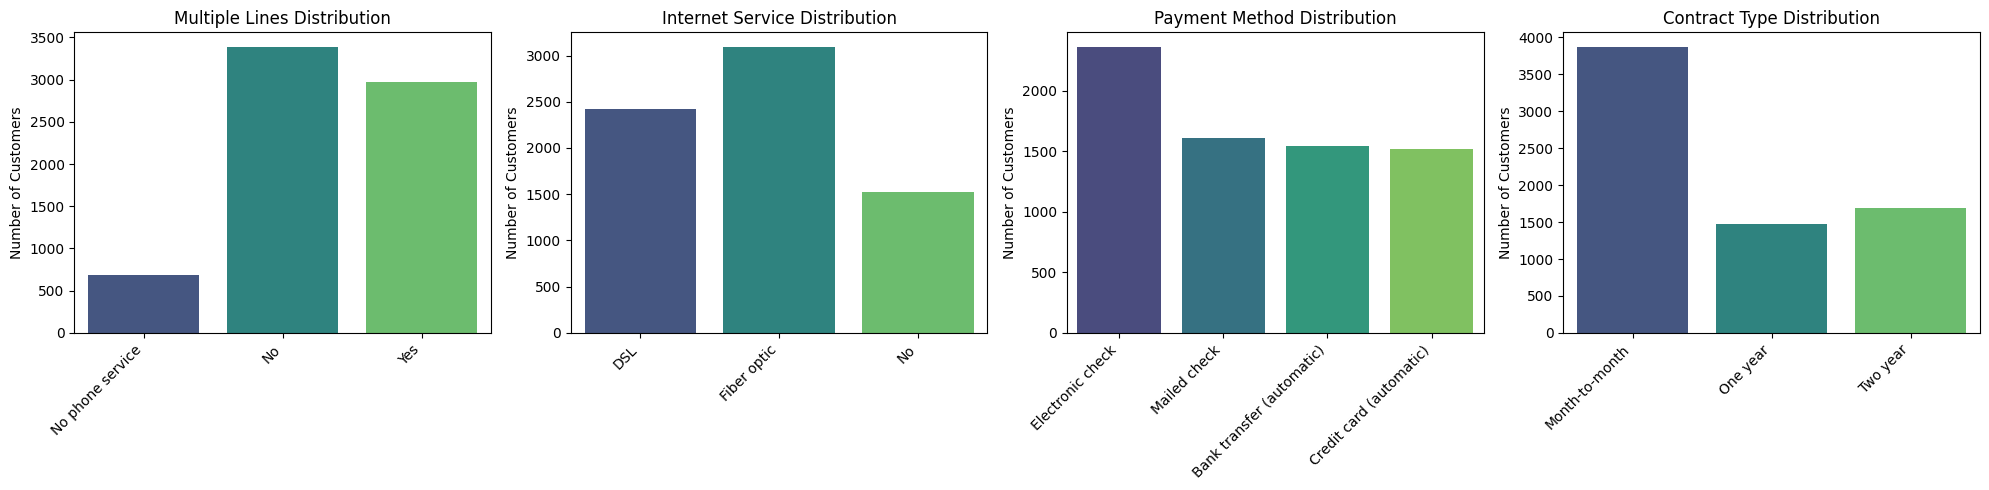

In [ ]:
# Proportion of customers across different categories

plt.figure(figsize=(20, 5)) # Adjusted figure size for a single row

# Multiple Lines
plt.subplot(1, 4, 1) # 1 row, 4 columns, first plot
sns.countplot(x='MultipleLines', data=df, palette='viridis', hue='MultipleLines', legend=False)
plt.title('Multiple Lines Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Internet Service
plt.subplot(1, 4, 2) # 1 row, 4 columns, second plot
sns.countplot(x='InternetService', data=df, palette='viridis', hue='InternetService', legend=False)
plt.title('Internet Service Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Payment Method
plt.subplot(1, 4, 3) # 1 row, 4 columns, third plot
sns.countplot(x='PaymentMethod', data=df, palette='viridis', hue='PaymentMethod', legend=False)
plt.title('Payment Method Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Contract
plt.subplot(1, 4, 4) # 1 row, 4 columns, fourth plot
sns.countplot(x='Contract', data=df, palette='viridis', hue='Contract', legend=False)
plt.title('Contract Type Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### **Interpretation:** Overall distribution of customers across key categorical features such as MultipleLines, InternetService`, PaymentMethod & Contract.
1.  **Contract Type:** Distribution of payment contracts is not balanced; majority of customers tend to make payments monthly (Month-to-month contracts), which often correlates with higher churn rates. Longer contract terms (One year, Two year) are less common but indicate greater customer commitment.
2.  **Paperless Billing:** A significant majority of customers tend to use paperless bills.
3.  **Payment Method:** Electronic check is most common payment method, followed by Mailed check, Bank transfer (automatic), Credit card (automatic).
4.  **Internet Service:** Customers using DSL internet service tend to be more loyal compared to Fiber optic users. Customers without internet service show even lower churn, which suggests that company should investigate shortcomings in their Fiber optic service and leverage the success of their DSL offerings. Overall, review of internet service offerings is recommended to reduce churn.

#### **2.2 Churn Distribution (Pie Chart)**

To understand proportion of churned vs. non-churned customers & assess class imbalance, which is critical for model training & evaluation.


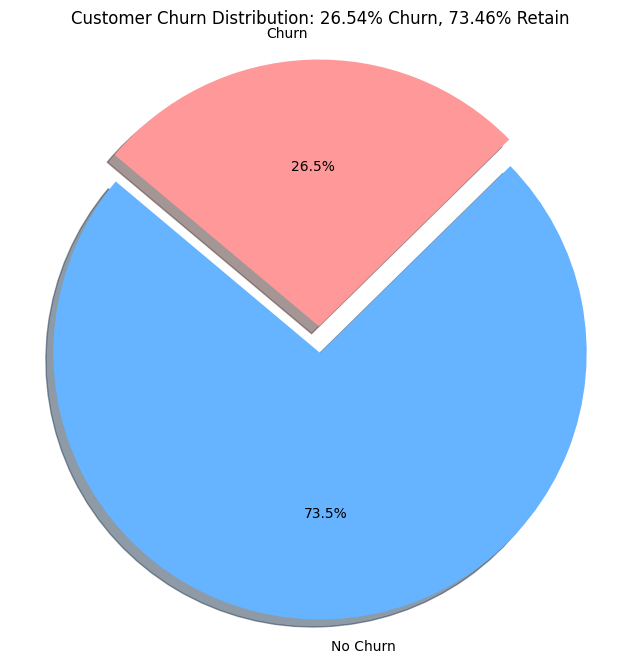

In [ ]:
# Determine the number of customers that churned(Yes) and not churned(No)
# Count of customer that will churn
cust_churn_yes_count = df[df.Churn == 'Yes'].shape[0]

# Count of customer that will not churn (retain)
cust_churn_no_count = df[df.Churn == 'No'].shape[0]

# Percentage of customer that will churn
cust_churn_yes_percent = round((cust_churn_yes_count / (cust_churn_yes_count + cust_churn_no_count) * 100),2)
# Percentage of customer that will not churn (retain)
cust_churn_no_percent = round((cust_churn_no_count / (cust_churn_yes_count + cust_churn_no_count) * 100 ),2)

# Prepare data for pie chart
labels = ['No Churn', 'Churn']
sizes = [cust_churn_no_count, cust_churn_yes_count]
colors = ['#66b3ff', '#ff9999'] # Blue for No Churn, Red for Churn
explode = (0.1, 0)  # Explode the 'Churn' slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title(f'Customer Churn Distribution: {cust_churn_yes_percent}% Churn, {cust_churn_no_percent}% Retain')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#### **2.3 Customer Churn Distribution (Count plot)**

Visualize absolute number of churned and non-churned customers, providing clear picture of class distribution.

#### **Interpretation:** Chart represents proportion of churned ('Yes') versus non-churned ('No') customers, clearly indicating class imbalance within dataset.

Churn distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


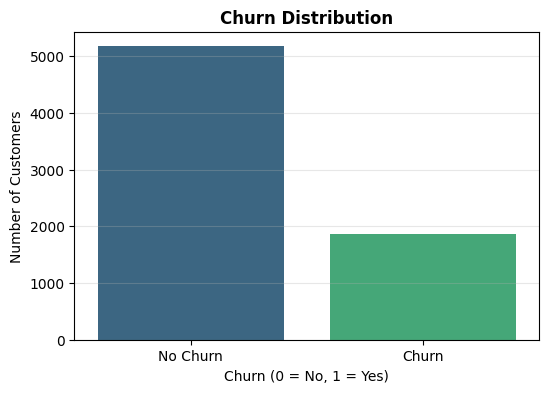

In [ ]:
print(f"Churn distribution:\n{df['Churn'].value_counts(normalize=True)}")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Churn Distribution', fontweight='bold')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **Interpretation:** Reinforces class imbalance, showing absolute numbers of customers who churn & those who remain.

#### **2.4 Correlation Heatmap for Numerical Features**
Heatmap to see Correlation between Numerical columns

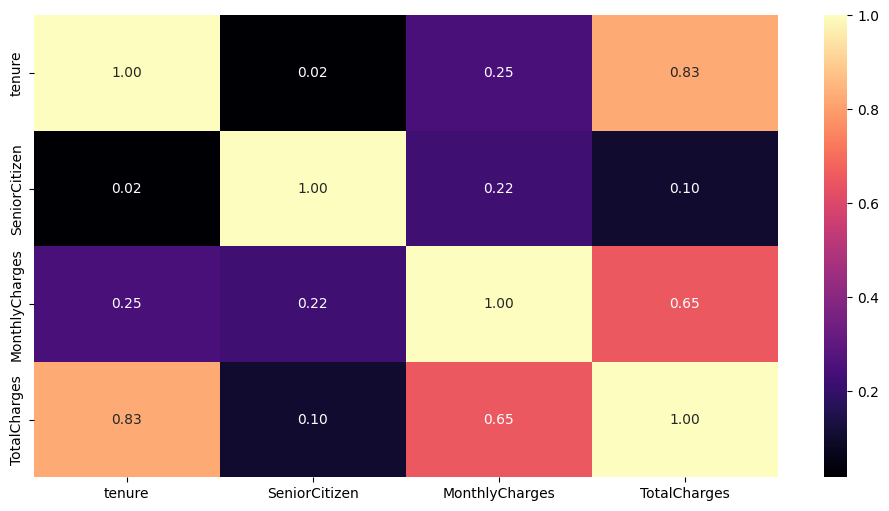

In [ ]:
plt.figure(figsize = (12,6))
corr = df[cols_for_num_variation].corr()
sns.heatmap(corr, annot=True, fmt =".2f", cmap="magma")
plt.show()

#### **Interpretation:** Strong positive correlations between tenure & TotalCharges & moderate negative correlations between tenure, TotalCharges, and Churn.

#### **Interpretation**: Strong relationship between tenure and TotalCharges, MonthlyCharges & TotalCharges.

#### **2.4 Churn Barplot based on Customer Demographics**
Visualize how customer demographics (gender, partner, senior citizen status, dependents, phone service, and paperless billing) influence churn rates.

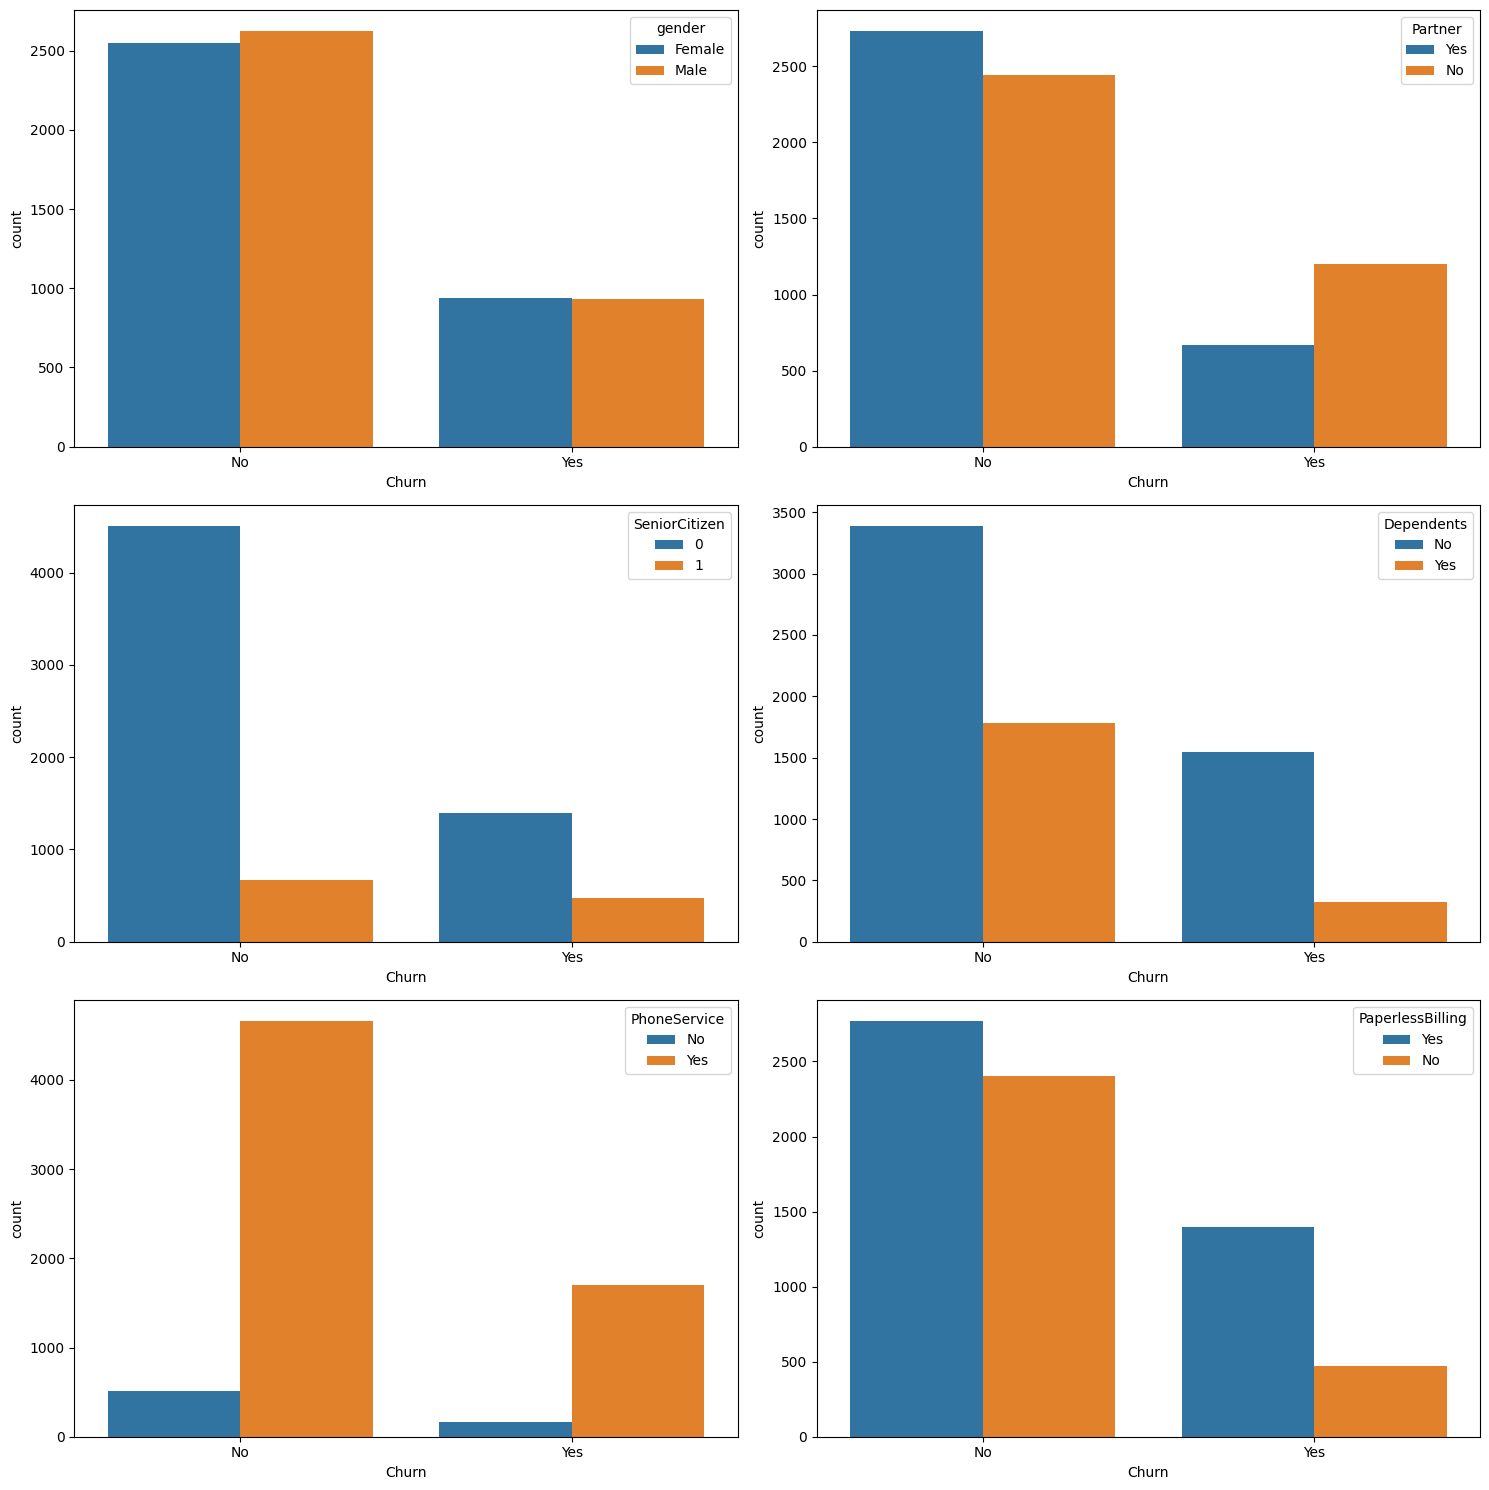

In [ ]:
# Define mappings for original binary columns that were encoded to 0/1
# This ensures that original string labels are used for plotting axes/legends
churn_x_labels = {0: 'No', 1: 'Yes'}
gender_hue_labels = {0: 'Female', 1: 'Male'}
yes_no_hue_labels = {0: 'No', 1: 'Yes'}

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Helper function to apply labels to axes and legends
def apply_plot_labels(ax, hue_col):
    # Set x-axis labels for 'Churn' (0/1 to 'No Churn'/'Churn')
    ax.set_xticks([0, 1])
    ax.set_xticklabels([churn_x_labels[0], churn_x_labels[1]])
    ax.set_xlabel('Churn') # Set a clear label for the x-axis

    # Determine the correct mapping for the hue legend
    if hue_col == 'gender':
        labels_map = gender_hue_labels
    elif hue_col in ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        labels_map = yes_no_hue_labels
    else:
        labels_map = None # This case should not be reached for the specified plots

    if labels_map:
        handles, current_labels = ax.get_legend_handles_labels()
        # Ensure labels are integers for mapping, as sns.countplot converts them to strings
        new_labels = [labels_map.get(label, label) for label in current_labels]
        ax.legend(handles, new_labels, title=hue_col)
    else:
        # If no specific mapping, just ensure the legend has a title (fallback)
        ax.legend(title=hue_col)


# Plot 1: Churn vs Gender
sns.countplot(x='Churn', hue='gender', data=df, ax=axs[0, 0])
apply_plot_labels(axs[0, 0], 'gender')

# Plot 2: Churn vs Partner
sns.countplot(x='Churn', hue='Partner', data=df, ax=axs[0, 1])
apply_plot_labels(axs[0, 1], 'Partner')

# Plot 3: Churn vs SeniorCitizen
sns.countplot(x='Churn', hue='SeniorCitizen', data=df, ax=axs[1, 0])
apply_plot_labels(axs[1, 0], 'SeniorCitizen')

# Plot 4: Churn vs Dependents
sns.countplot(x='Churn', hue='Dependents', data=df, ax=axs[1, 1])
apply_plot_labels(axs[1, 1], 'Dependents')

# Plot 5: Churn vs PhoneService
sns.countplot(x='Churn', hue='PhoneService', data=df, ax=axs[2, 0])
apply_plot_labels(axs[2, 0], 'PhoneService')

# Plot 6: Churn vs PaperlessBilling
sns.countplot(x='Churn', hue='PaperlessBilling', data=df, ax=axs[2, 1])
apply_plot_labels(axs[2, 1], 'PaperlessBilling')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Interpretation**: Based on Bar chart visualization of binary categorical features, the following insights are observed.

* **Gender**: Both female and male customers are predominantly in the non-churn (No) category, with over 2500 customers in each group continuing their subscriptions. Approximately 900–950 customers from each group have churned. This indicates that gender does not significantly influence churn behavior.
* **Partner**: Customers with a partner (Yes) are more likely to not churn (continue their subscriptions), whereas customers without a partner (No) show a higher proportion of churn (Yes). This suggests that having a partner is associated with better customer retention.
* **Senior Citizen**: Both senior (1) and non-senior (0) customers are predominantly in the non-churn (No) category. However, non-senior customers form a much larger portion of the dataset. Churn exists in both groups, indicating that age category alone is not a strong differentiator.
* **Dependents**: Customers without dependents are more likely to churn, while customers with dependents are more likely to not churn (retain). This suggests that having dependents may positively influence customer retention.
* **Phone Service**: Most customers have phone service (Yes) in both churn and non-churn categories. Although customers with phone service dominate overall, churn is still present among them, indicating that phone service alone does not significantly reduce churn.
* **Paperless Billing**: Customers using paperless billing (Yes) are more prevalent in both churn and non-churn groups. However, churn is relatively higher among customers with paperless billing compared to those without it, suggesting a potential association that may require further investigation.
* Most binary features show limited differentiation between churn and non-churn customers, except for features like Partner and Dependents, which exhibit clearer patterns. This suggests that additional factors such as pricing, contract type, or service quality may play a more significant role in influencing customer churn.



#### **2.5 Churn Barplot based on Service Type**

Visualize how various service types (e.g., Multiple Lines, Internet Service, Online Security) influence customer churn rates.

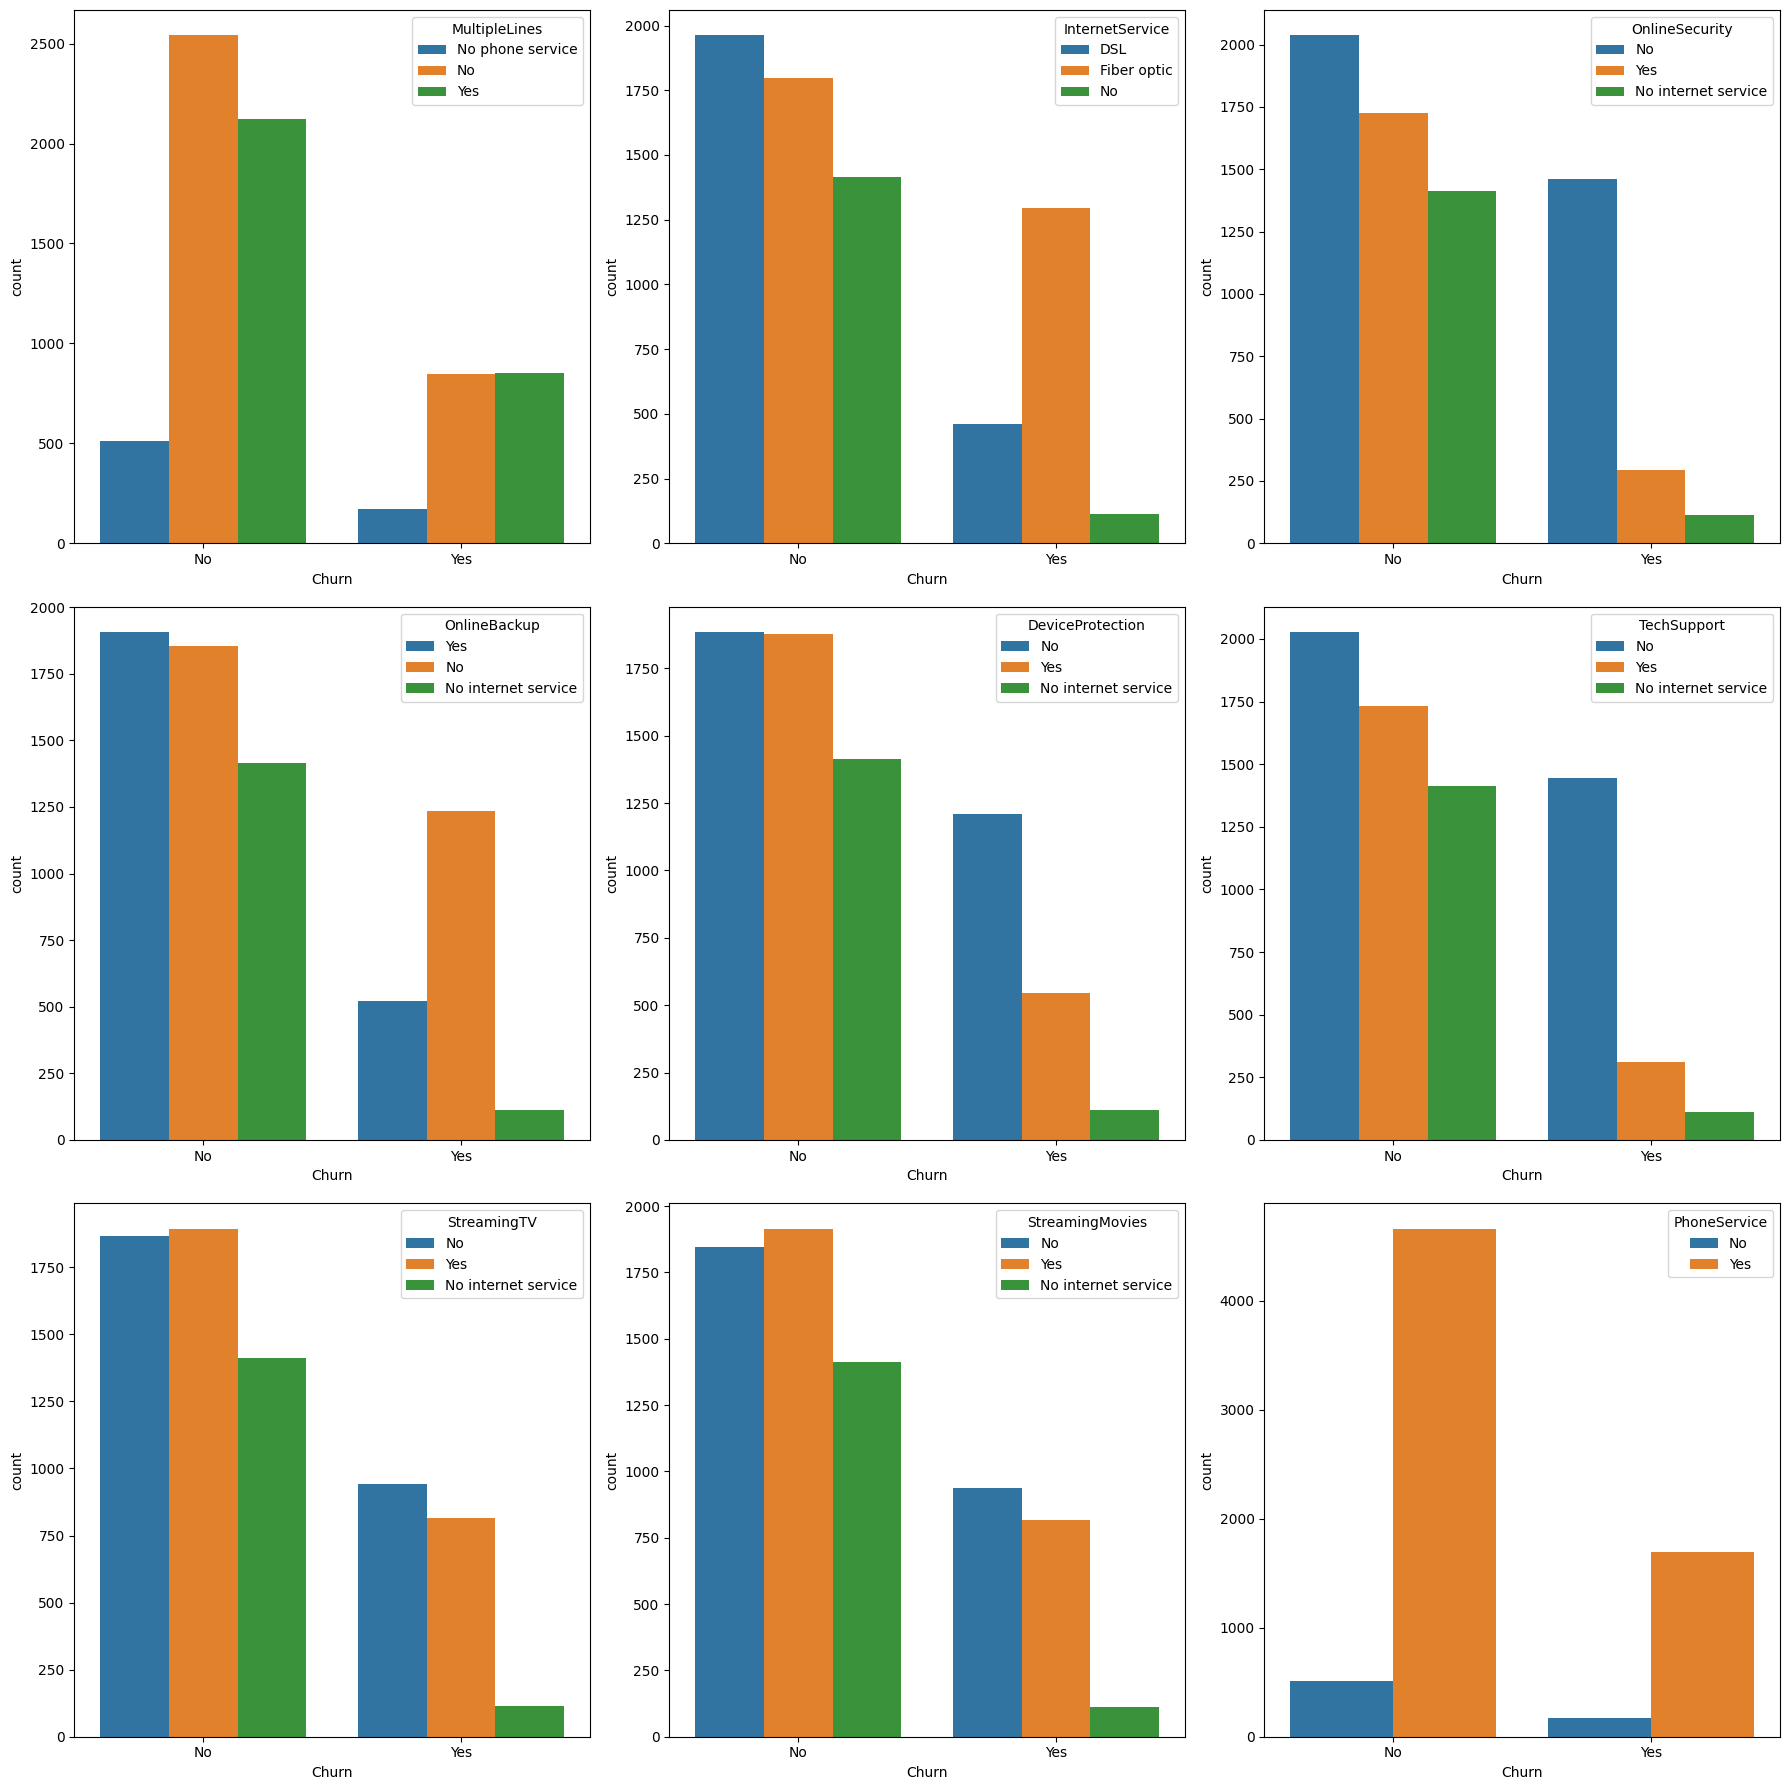

In [ ]:

# Bar chart visualization of multi-category features against churn target targets
fig,axs=plt.subplots(3,3, figsize=(18,18)) # Changed to 3 rows, 3 columns
sns.countplot(x='Churn',hue='MultipleLines',data=df,ax=axs[0,0])
sns.countplot(x='Churn',hue='InternetService',data=df,ax=axs[0,1])
sns.countplot(x='Churn',hue='OnlineSecurity',data=df,ax=axs[0,2]) # Adjusted index
sns.countplot(x='Churn',hue='OnlineBackup',data=df,ax=axs[1,0]) # Adjusted index
sns.countplot(x='Churn',hue='DeviceProtection',data=df,ax=axs[1,1]) # Adjusted index
sns.countplot(x='Churn',hue='TechSupport',data=df,ax=axs[1,2]) # Adjusted index
sns.countplot(x='Churn',hue='StreamingTV',data=df,ax=axs[2,0]) # Adjusted index
sns.countplot(x='Churn',hue='StreamingMovies',data=df,ax=axs[2,1]) # Adjusted index
sns.countplot(x='Churn',hue='PhoneService',data=df,ax=axs[2,2]) # Adjusted index
plt.tight_layout()
plt.show()

**Interpretation**: Based on Bar chart visualization of multi-categorical features, the following insights are observed.
*   **High Churn Risk Services**: Customers using Fiber optic internet service and those without Online Security, Online Backup, Device Protection, or Tech Support show significantly higher propensity to churn, such services appear to be key drivers of retention.
*   **Limited Impact Services**: Multiple Lines, Streaming TV & Streaming Movies show limited differentiation in churn behavior, suggesting they may have less influence on customer retention.
*   Overall, features like Internet Service (especially Fiber Optic), Online Security, Online Backup, Device Protection, and Tech Support are strong predictors of churn, while others have minimal predictive importance.

#### **2.6 Churn Barplot based on Payment Type**

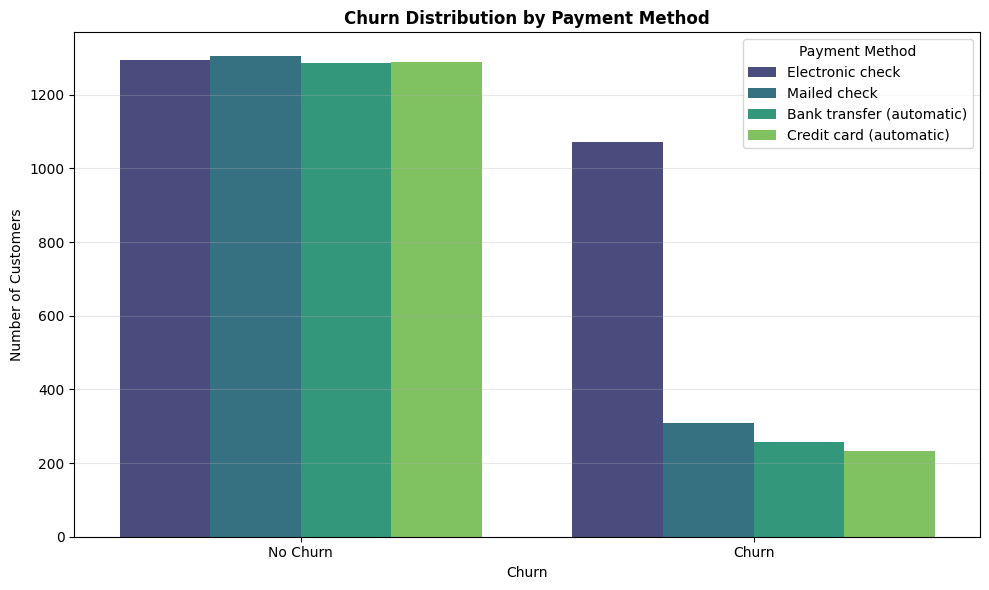

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', hue='PaymentMethod', data=df, palette='viridis')
plt.title('Churn Distribution by Payment Method', fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Payment Method')
plt.tight_layout()
plt.show()

#### **Interpretation:** Bar plot illustrates customers utilizing Electronic check payment methods exhibit considerably higher churn rate, while those on Bank transfer (automatic) & Credit card (automatic) show lower churn, indicating strong correlation between payment method & customer retention.

#### **2.7 Churn vs. Tenure, Monthly, Total Charges & Contract Type**

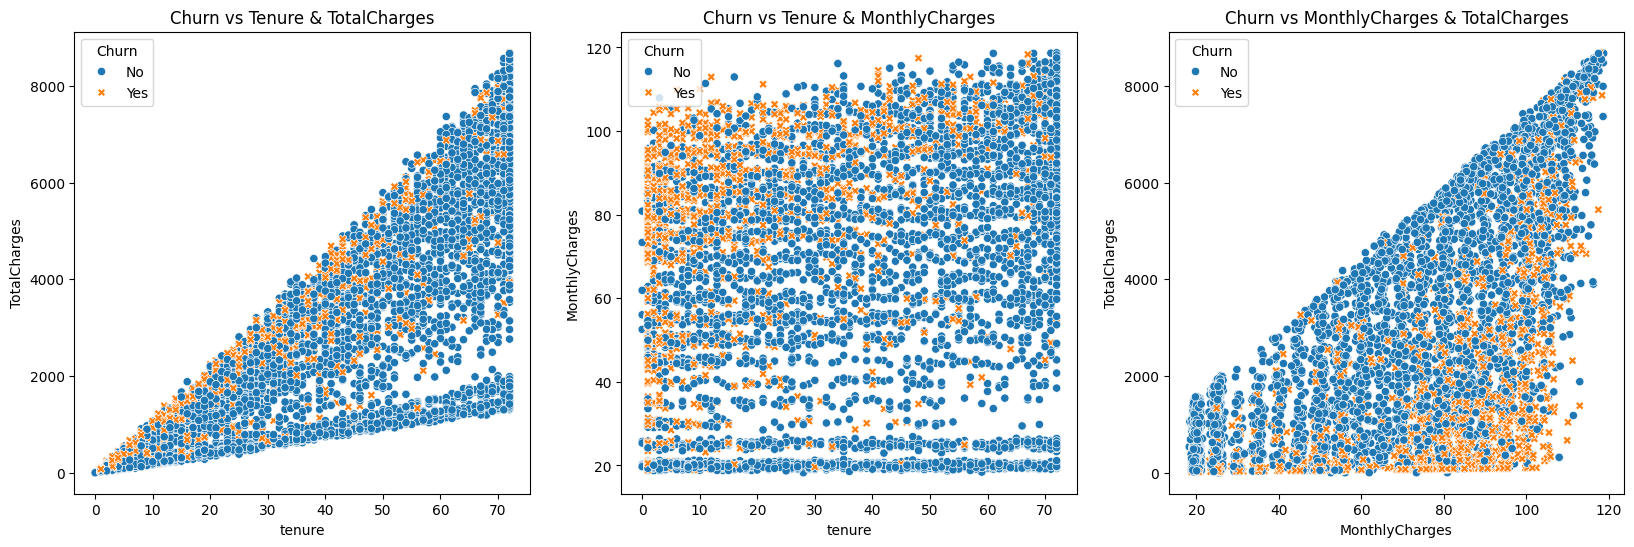

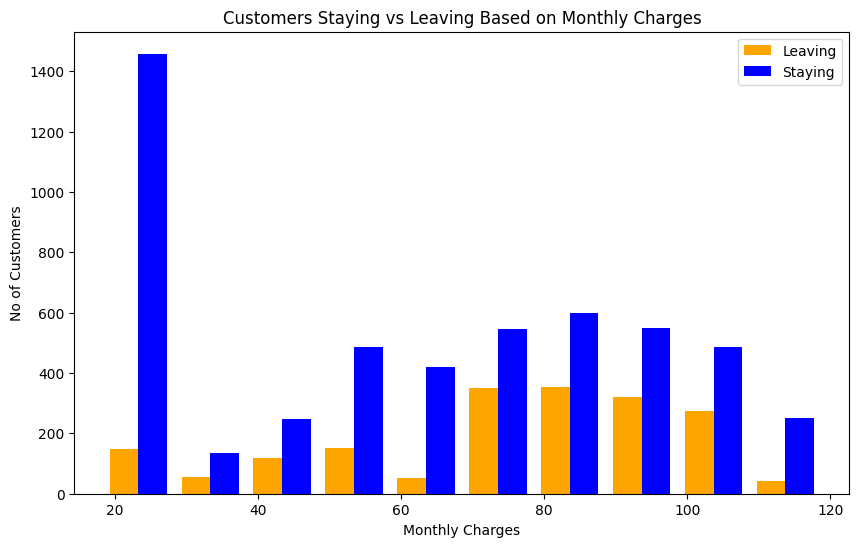

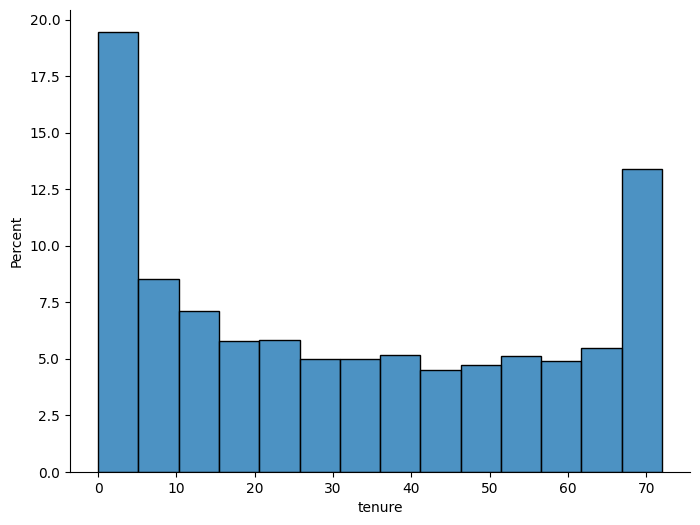

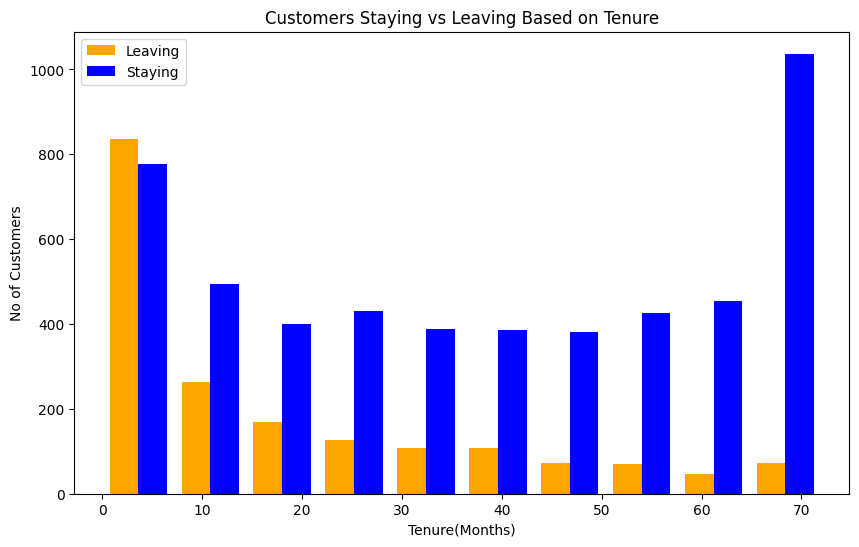

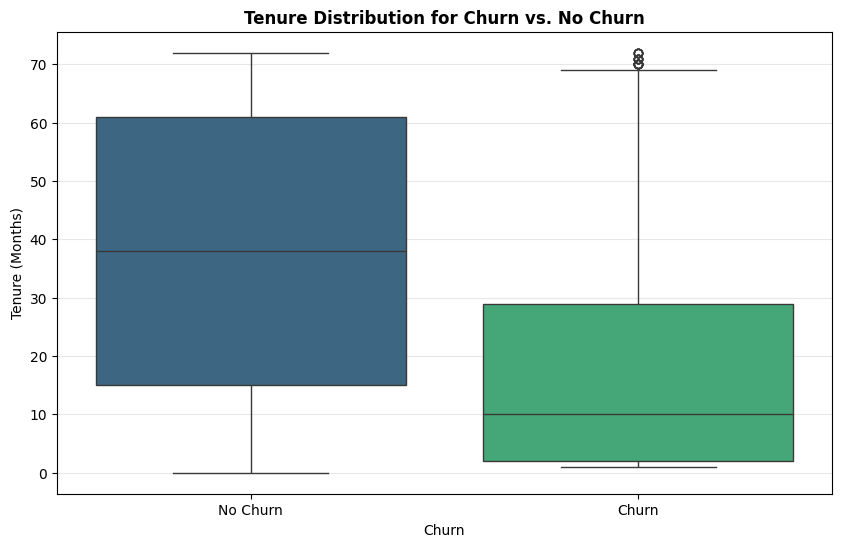

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Churn vs Tenure and Total Charges
sns.scatterplot(data=df, x="tenure", y="TotalCharges", hue="Churn", style="Churn", ax=axs[0])
axs[0].set_title('Churn vs Tenure & TotalCharges')

# Plot 2: Churn vs Tenure and Monthly Charges
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", style="Churn", ax=axs[1])
axs[1].set_title('Churn vs Tenure & MonthlyCharges')

# Customer churn with respect to monthly charges.
monthly_charges_churn_yes = df[df.Churn == 'Yes'].MonthlyCharges
monthly_charges_churn_no = df[df.Churn == 'No'].MonthlyCharges

plt.figure(figsize=(10,6))
plt.hist([monthly_charges_churn_yes, monthly_charges_churn_no], color=['orange', 'blue'], label= ['Leaving', 'Staying'])
plt.xlabel('Monthly Charges')
plt.ylabel('No of Customers')
plt.title('Customers Staying vs Leaving Based on Monthly Charges')
plt.legend()

# Plot 3: Churn vs Monthly and Total Charges
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn", style="Churn", ax=axs[2])
axs[2].set_title('Churn vs MonthlyCharges & TotalCharges')

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(data=df, x='tenure', stat='percent', multiple='dodge', ax=ax, binwidth=5, alpha=0.8)
# sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncol=3, title='', frameon=False) # Removed as 'hue' is removed

sns.despine()
plt.show()

# Effect of tenure on customer churn
tenure_churn_yes = df[df.Churn == 'Yes'].tenure
tenure_churn_no = df[df.Churn == 'No'].tenure

plt.figure(figsize=(10,6))
plt.hist([tenure_churn_yes, tenure_churn_no], color=['orange', 'blue'], label= ['Leaving', 'Staying'])
plt.xlabel('Tenure(Months)')
plt.ylabel('No of Customers')
plt.title('Customers Staying vs Leaving Based on Tenure')
plt.legend()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Tenure Distribution for Churn vs. No Churn', fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.tight_layout()
plt.show()

#### **Interpretation:** Plots ollectively illustrate complex relationships between tenure, MonthlyCharges, TotalCharges & customer Churn.
*   **Churn vs Tenure & TotalCharges**: Customers with shorter tenures & lower total charges are generally more prone to churn. Longer tenure with higher total charges can still lead to churn, indicating dissatisfaction even among long-term, high-value customers which contrasts with simpler expectation that long-term customers always loyal.
*   **Churn vs Tenure & MonthlyCharges**: Churn is notably high among customers in 0-20 month tenure range who also have large monthly charges, which suggests new customers facing high monthly bills are particularly at risk of leaving.
*   **Churn vs MonthlyCharges & TotalCharges**: Clear positive correlation between monthly & total charges. Interestingly, churn is more prevalent in segments with higher monthly charges but relatively lower total charges, pattern often implies customers paying high monthly rates but not accumulating significant total charges (due to short tenure) more likely to churn.
*   **Churn vs ContractType**: Customers with Month-to-month contracts tend to have much shorter tenures & more numerous, suggesting a higher churn risk for this contract type.
*   **Churn vs Tenure**: Customers with shorter tenures (especially below 20 months) have significantly higher tendency to churn compared to long-term customers.

#### **2.8 Churn vs. Demographic & Service-Related Charges**

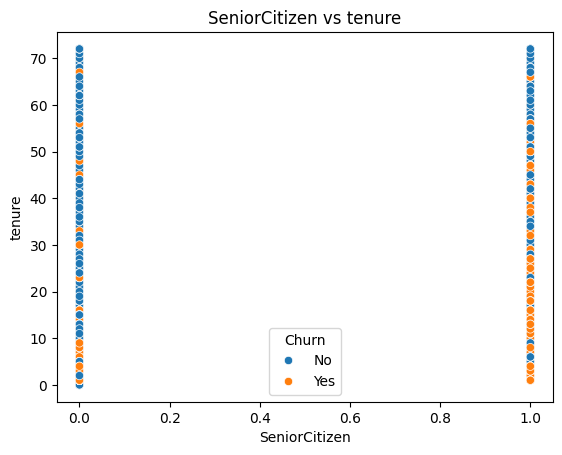

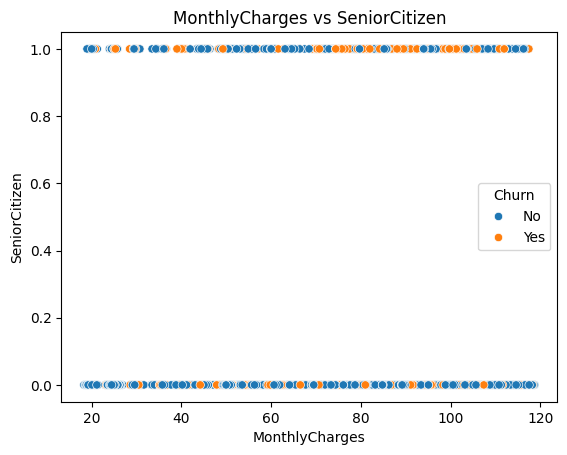

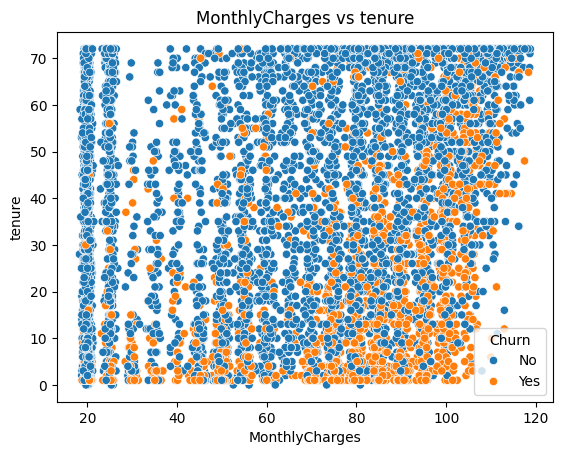

In [ ]:
# Relationship between TotalCharges vs tenure features
sns.scatterplot(x="SeniorCitizen", y = "tenure" , hue="Churn",  data = df)
plt.title('SeniorCitizen vs tenure')
plt.show()

# Relationship between MonthlyCharges vs tenure features
sns.scatterplot(x="MonthlyCharges", y = "SeniorCitizen" , hue="Churn",  data = df)
plt.title('MonthlyCharges vs SeniorCitizen')
plt.show()

# Relationship between MonthlyCharges vs TotalCharges features
sns.scatterplot(x="MonthlyCharges", y = "tenure" , hue="Churn",  data = df)
plt.title('MonthlyCharges vs tenure')
plt.show()

#### **Interpretation**: Based on plot visualizations between numerical & demographic features, following insights observed.
*   **SeniorCitizen vs. tenure (with Churn hue):** SeniorCitizen status does not present clear, direct linear relationship with tenure that strongly influences churn. Both senior & non-senior customers exhibit churn across various tenure lengths, indicating interaction between factors & churn is more complex than simple direct correlation.
*   **MonthlyCharges vs. SeniorCitizen (with Churn hue):** MonthlyCharges & SeniorCitizen status do not have a straightforward interactive effect that linearly drives churn. Churn is distributed across different monthly charge ranges for both demographics, suggesting other underlying factors might be more dominant.
*   **MonthlyCharges vs. tenure (with Churn hue):** Customers with shorter tenure tend to have wider range of MonthlyCharges & higher propensity to churn. Conversely, customers with longer tenure generally exhibit higher MonthlyCharges but are less likely to churn. Churned customers are visibly concentrated in regions of lower tenure & also within segments of higher monthly charges but shorter tenures, highlighting that new customers or those with high initial monthly costs are at a higher risk of churn.
* While seniority itself doesn't show simple direct link to churn via tenure or monthly charges, combined view of tenure & MonthlyCharges strongly indicate early-stage customers or those incurring higher initial costs are particularly vulnerable to churn.

#### **2.9 Pairwise Relationships of Numerical Features with Churn**
Visualizes relationships between all numerical features simultaneously, including individual distributions & how interactions vary based on Churn target, which aids to identify complex patterns & dependencies not evident in univariate or bivariate analyses.

In [ ]:
sns.pairplot(df, hue="Churn")
plt.tight_layout()
plt.show()

#### **Interpretation:** Pairplot provides comprehensive visual overview of relationships between all pairs of numerical features & distribution with respect to churn. More number of customers tend to stay with company after first 10 months of service. As per which company can concentrate more on new customer & initial experience with service to increase customer retention.

#### **2.10 Churn Probability Calculation for Categorical Features**
Calculates probability of churn for each category within the categorical features, providing insights into which segments are most and least likely to churn.

In [ ]:
# Churn Probability for All categories

# This cell ensures that 'TotalCharges' is numeric and that 'column_numerical' and 'data_viz' are defined
# for the subsequent plotting cell to function correctly.

# Ensure TotalCharges is numeric and handle missing values
# This logic is extracted from prior data cleaning steps (cells FnAv6Q-rsfMr and 2HF7ajfOsfMs)
# to resolve the NameError and allow the plotting cell to run in its current position.
if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = 0

# Define column_numerical and data_viz, which are prerequisites for the next plotting cell
data_viz = df.copy()
column_numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Ensure 'Churn' column in data_viz is numerical (0/1) for palette mapping
data_viz['Churn'] = data_viz['Churn'].map({'No': 0, 'Yes': 1})

# Use the original DataFrame for categorical values, but the encoded Churn
df_temp = df.copy()
df_temp['Churn'] = df['Churn'] # Add the encoded Churn column (0/1) from `df`

# Explicitly encode 'Churn' column to 0/1 for crosstab columns
df_temp['Churn'] = df_temp['Churn'].map({'No': 0, 'Yes': 1})

columns_for_crosstab = df_temp['Churn'] # This will be the columns of the crosstab (0 and 1)

attr_crosstab = pd.DataFrame()

# List of original categorical columns, excluding the target and customerID
# Numerical columns like 'tenure', 'MonthlyCharges', 'TotalCharges' are excluded from this analysis
original_categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

for col in original_categorical_cols:
  # Create crosstab for each attribute. Normalizing by index gives churn/retain % for each category value
  index = df_temp[col]
  ct = pd.crosstab(index=index, columns=columns_for_crosstab, normalize='index', colnames=[None]).reset_index()

  # Construct the 'attribute' string as 'Original Column Name (Value)'
  col_titleize = inflection.titleize(col)
  ct['attribute'] = ct[col].apply(lambda x: f'{col_titleize} ({x})')

  # Select and reorder columns for concatenation, keeping 0 and 1 as column names
  # 0 is 'No Churn' (Retain), 1 is 'Yes Churn' (Churn)
  ct_selected = ct[['attribute', 0, 1]]

  # Concatenate to the main attr_crosstab
  attr_crosstab = pd.concat([attr_crosstab, ct_selected])

# Sort the final DataFrame by '1' (Churn_Percentage) descending
attr_crosstab = attr_crosstab.sort_values(1, ascending=False).reset_index(drop=True)

# Format percentages to 3 decimal places for display consistency
attr_crosstab[0] = attr_crosstab[0].round(3)
attr_crosstab[1] = attr_crosstab[1].round(3)

# Rename columns 0 and 1
attr_crosstab.rename(columns={0: 'retain', 1: 'churn'}, inplace=True)

# Display the styled DataFrame
attr_crosstab.style.background_gradient()

#### **Interpretation:** Calculated and consolidated churn & retention probabilities for each category across various categorical features to serve as foundation for subsequent visualizations and deeper insights.

#### **2.10.1 Top 5 Categories with Highest Churn Probability**

In [ ]:
# Top 5 Churn probabilities
fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(data=attr_crosstab.iloc[:5], x='churn', y='attribute', ax=ax, color='#FC4F30')

ax.bar_label(ax.containers[0], padding=3, fmt='%.2f', fontsize=14, fontweight='medium')
ax.grid(False, axis='y')
ax.set_title('Top 5 Categories with the Highest Probability to Churn')

ax.set_xlim(0, 1)
ax.set_ylabel('')
ax.set_xlabel('Churn Probability')

ax.set_xticklabels([])
sns.despine(left=True, bottom=True)
plt.show()

#### **Interpretation:** Bar plot identifies top 5 categorical segments with highest churn probabilities, pointing to areas requiring urgent business intervention.

#### **2.10.2 Top 5 Categories with Lowest Churn Probability**

In [ ]:
# Top 5 Retain probability
fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(data=attr_crosstab.iloc[-5:].sort_values('churn'), x='churn', y='attribute', ax=ax, color='#008FD5')

ax.bar_label(ax.containers[0], padding=3, fmt='%.2f', fontsize=14, fontweight='medium')
ax.grid(False, axis='y')
ax.set_title('Top 5 Categories with the Lowest Probability to Churn')

ax.set_xlim(0, 1)
ax.set_ylabel('')
ax.set_xlabel('Churn Probability')

ax.set_xticklabels([])
sns.despine(left=True, bottom=True)
plt.show()

#### **Interpretation:** Bar plot showcases top 5 categorical segments with the lowest churn probabilities, offering insights into factors that contribute to strong customer loyalty.

#### **2.11 Multivariate Scatter Plots of Numerical Features with Churn**

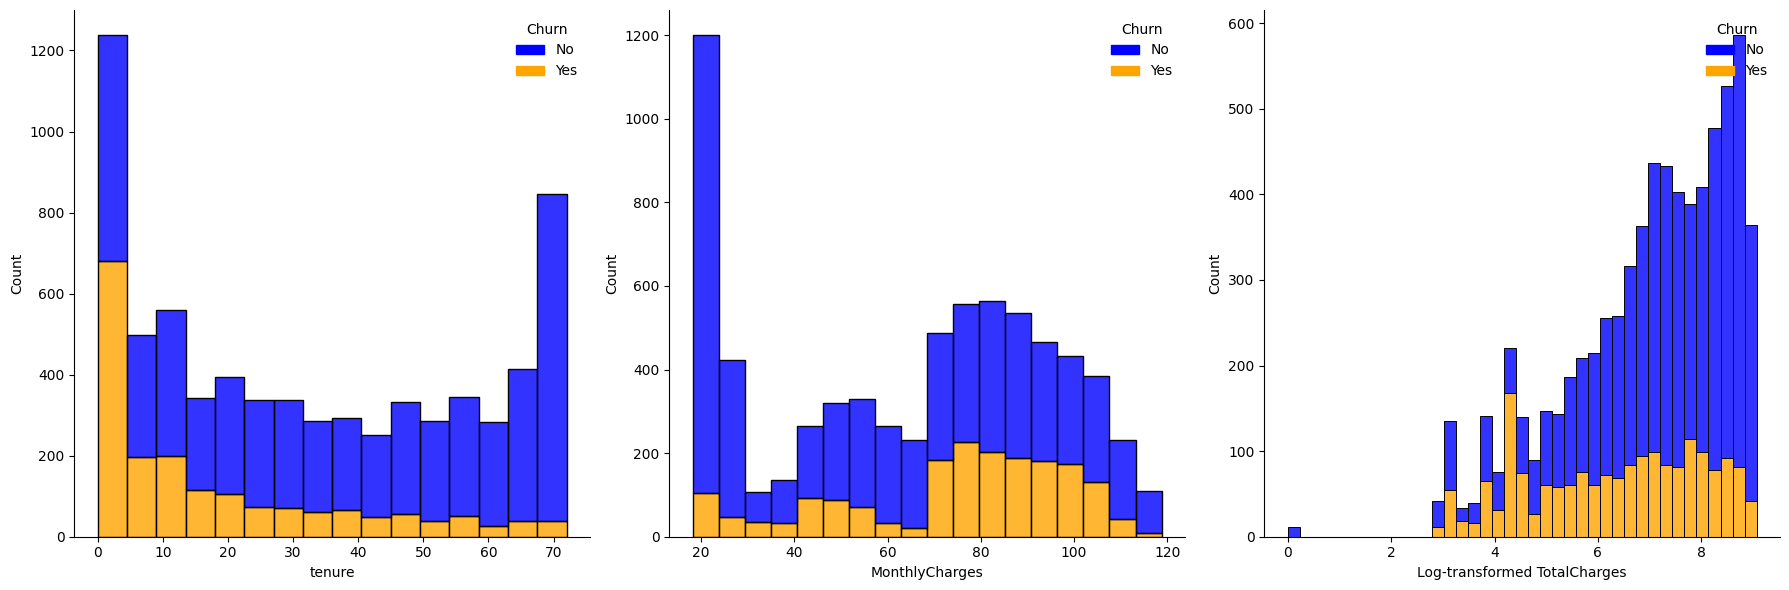

In [ ]:
 # Churn distribution across numerical features.
fig, ax = plt.subplots(1, 3, figsize=(18,6))

# Define the new legend labels mapping with colors
legend_labels_map = {0: 'No', 1: 'Yes'}

for i, col in enumerate(column_numerical):
  if col == 'TotalCharges':
    # Explicitly convert to numeric (float) with error handling using pd.to_numeric, then fill NaNs, before applying log transform
    numeric_total_charges = pd.to_numeric(data_viz[col], errors='coerce').fillna(0)
    sns.histplot(data=data_viz, x=np.log1p(numeric_total_charges), hue='Churn', multiple='stack', ax=ax[i], alpha=0.8, palette={0: 'blue', 1: 'orange'})
    ax[i].set_xlabel(f'Log-transformed {col}') # Update x-label to reflect transformation
  else:
    sns.histplot(data=data_viz, x=col, hue='Churn', multiple='stack', ax=ax[i], alpha=0.8, palette={0: 'blue', 1: 'orange'})

  # Manually create legend handles and labels to ensure they are visible
  # This bypasses potential issues with get_legend_handles_labels() not returning what's expected.
  legend_patches = [
      mpatches.Patch(color='blue', label='No'),
      mpatches.Patch(color='orange', label='Yes')
  ]
  ax[i].legend(handles=legend_patches, title='Churn', loc='upper right', bbox_to_anchor=(1, 1), ncol=1, frameon=False)

plt.tight_layout()
sns.despine()
plt.show()

#### **Interpretation:** Churn (orange) is distributed across different ranges of tenure, MonthlyCharges & TotalCharges, revealing specific segments with higher churn concentration. For lowest monthly rates(between 20 and 40), customer retention is the highest. But customer attrition increases for monthly charges between 70 & 100. As per which, company can reduce monthly charges or add more value to service for same price to increase customer retention.

#### **2.12 Average Monthly Charges by Streaming Service Type, Online Securitye**

In [ ]:
# See the comparison of streamingTV features with StreamingMovies against the number of MonthlChargers each month
print(df.groupby(by=['StreamingTV'])['MonthlyCharges'].mean().sort_values(), '\n')
print(df.groupby(by=['StreamingMovies'])['MonthlyCharges'].mean().sort_values(), '\n')


StreamingTV
No internet service    21.079194
No                     65.387687
Yes                    88.736738
Name: MonthlyCharges, dtype: float64 

StreamingMovies
No internet service    21.079194
No                     65.434147
Yes                    88.475714
Name: MonthlyCharges, dtype: float64 



#### **Interpretation:** Average MonthlyCharges for customers based on StreamingTV & StreamingMovies subscriptions, with Yes categories generally having higher charges.

In [ ]:
# See the comparison of the OnlineSecurity feature with OnlineBackup against the number of MonthlChargers each month
print(df.groupby(by=['OnlineSecurity'])['MonthlyCharges'].mean().sort_values(), '\n')
print(df.groupby(by=['OnlineBackup'])['MonthlyCharges'].mean().sort_values(), '\n')

OnlineSecurity
No internet service    21.079194
No                     75.693067
Yes                    78.838732
Name: MonthlyCharges, dtype: float64 

OnlineBackup
No internet service    21.079194
No                     71.938002
Yes                    83.081597
Name: MonthlyCharges, dtype: float64 



#### **Interpretation:** Average MonthlyCharges for customers based on their OnlineSecurity & OnlineBackup services, indicating customers with such services tend to have higher monthly bills.

#### **2.13 Payment Method Distribution by Contract, Internet Service Type**

In [ ]:
# View the duration of the customer with the option to use the payment method
print(df.groupby(by=['Contract'])['PaymentMethod'].value_counts(normalize = True))

Contract        PaymentMethod            
Month-to-month  Electronic check             0.477419
                Mailed check                 0.230452
                Bank transfer (automatic)    0.152000
                Credit card (automatic)      0.140129
One year        Credit card (automatic)      0.270197
                Bank transfer (automatic)    0.265445
                Electronic check             0.235574
                Mailed check                 0.228785
Two year        Credit card (automatic)      0.342773
                Bank transfer (automatic)    0.332743
                Mailed check                 0.225369
                Electronic check             0.099115
Name: proportion, dtype: float64


#### **Interpretation:** Customers on month-to-month contracts predominantly use less automated payment methods (electronic/mailed checks), whereas those with longer contracts show a strong preference for stable, automatic payments, suggesting higher customer commitment with longer terms.

In [ ]:
# View the types of internet available with the option of using the payment method
print(df.groupby(by=['InternetService'])['PaymentMethod'].value_counts(normalize = True))


InternetService  PaymentMethod            
DSL              Electronic check             0.267658
                 Mailed check                 0.253201
                 Credit card (automatic)      0.245353
                 Bank transfer (automatic)    0.233788
Fiber optic      Electronic check             0.515181
                 Bank transfer (automatic)    0.208656
                 Credit card (automatic)      0.192829
                 Mailed check                 0.083333
No               Mailed check                 0.485583
                 Bank transfer (automatic)    0.217562
                 Credit card (automatic)      0.216907
                 Electronic check             0.079948
Name: proportion, dtype: float64


#### **Interpretation:** Payment method choices vary significantly by internet service: Fiber optic users strongly prefer electronic checks, while customers without internet service predominantly rely on mailed checks, indicating differing digital engagement levels across segments.

#### **2.14 Average Monthly & Total Charges for Churning Customers (by Senior Citizen Status)**

In [ ]:
condition = df["Churn"] == "Yes"
customer_churn = df[condition].groupby(["SeniorCitizen"]).agg(mean_monthlycharges = ("MonthlyCharges", "mean"),
                                                    mean_totalcharges = ("TotalCharges","mean")).reset_index()
customer_churn

,SeniorCitizen,mean_monthlycharges,mean_totalcharges
0,0,72.298098,1421.767229
1,1,80.713445,1853.792332


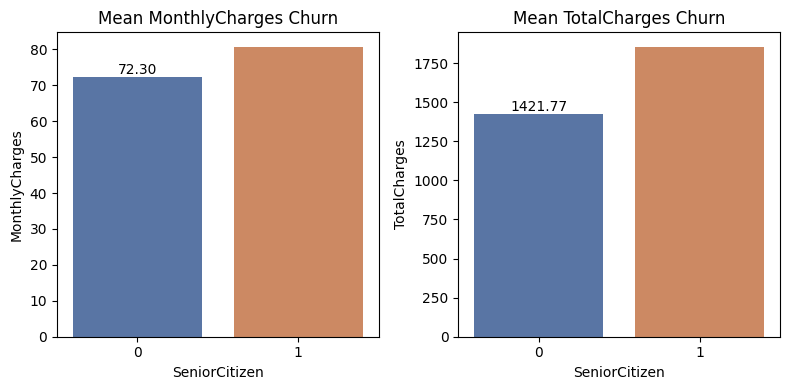

In [ ]:
plt.figure(figsize = (8,4))

#Average monthlycharges churn barplot
plt.subplot(1,2,1)
ax = sns.barplot(data = customer_churn, x = "SeniorCitizen", y="mean_monthlycharges", hue="SeniorCitizen", palette="deep", legend=False)
ax.bar_label(ax.containers[0], color ="Black", fmt = "%.2f")
ax.set_title("Mean MonthlyCharges Churn")
ax.set_ylabel("MonthlyCharges")

#Average totalcharges churn barplot
plt.subplot(1,2,2)
ax = sns.barplot(data = customer_churn, x = "SeniorCitizen", y="mean_totalcharges", hue="SeniorCitizen", palette="deep", legend=False)
ax.bar_label(ax.containers[0], color ="Black", fmt = "%.2f")
ax.set_title("Mean TotalCharges Churn")
ax.set_ylabel("TotalCharges")
plt.tight_layout()
plt.show()

#### **Interpretation:** Calculates mean MonthlyCharges & TotalCharges for churned customers, distinguishing between senior & non-senior citizens, indicating churned senior citizens have notably higher average MonthlyCharges & TotalCharges compared to non-senior counterparts which financial aspect, represented by higher bills, could be a more significant driver for churn among senior customers.

#### **2.15 Churn by Total Services (Senior vs. Non-Senior Citizens)**

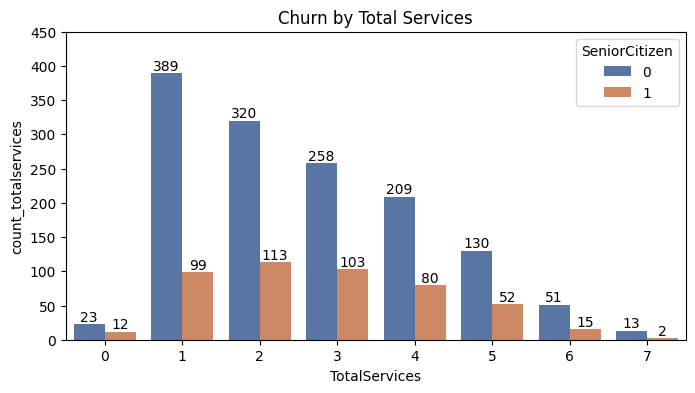

In [ ]:
plt.figure(figsize=(8,4))
ax = sns.barplot(data = services_churn, x = "TotalServices", y ="count_totalservices", hue="SeniorCitizen", palette="deep")
ax.bar_label(ax.containers[0], color="Black")
ax.bar_label(ax.containers[1], color="Black")
ax.set_title("Churn by Total Services")
ax.set_ylim(ymax = 450)
plt.show()

#### **Interpretation:** Visualizes churn counts by total number of services, suggesting customers with 1 to 3 services have higher propensity to churn.

#### **2.16 Churn Counts for Senior Customers by Tenure**

In [ ]:
condition = (df["Churn"] == "Yes") & (df["SeniorCitizen"] == 1)
tenure_churn = df[condition].groupby(["SeniorCitizen","tenure"]).agg(count = ("tenure","count") ).reset_index().sort_values("count", ascending = False).head(10)
tenure_churn

,SeniorCitizen,tenure,count
0,1,1,74
1,1,2,30
2,1,3,20
4,1,5,15
7,1,8,15
3,1,4,13
14,1,15,12
26,1,27,11
15,1,16,11
6,1,7,11


#### **Interpretation:** Quantifies churn among senior citizens by tenure, highlighting early tenure (e.g., 1 month) has highest churn count.

#### **2.17 Senior Customers with Highest Churn by Tenure**

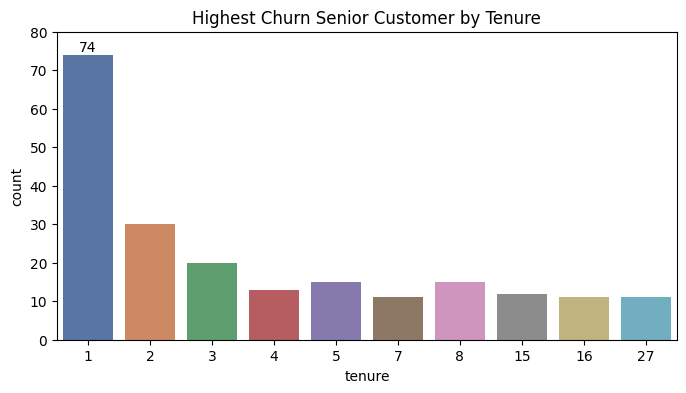

In [ ]:
plt.figure(figsize=(8,4))
ax = sns.barplot(data = tenure_churn, x = "tenure", y ="count", hue="tenure", palette="deep", legend=False)
ax.bar_label(ax.containers[0], color="Black")
ax.set_title("Highest Churn Senior Customer by Tenure")
ax.set_ylim(ymax = 80)
plt.show()

#### **Interpretation:** Senior customers are most likely to churn within their first month of service, suggesting an issue with initial experience or onboarding.

#### **2.18 Feature Engineering: Creating 'TotalServices'**

In [ ]:
# Create new feature (Feature Engineering)
df['TotalServices'] = (df[['PhoneService', 'InternetService', 'OnlineSecurity',
                                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                                       'StreamingTV', 'StreamingMovies']]== 'Yes').sum(axis=1)

#### **Interpretation:** This cell creates a new feature, `TotalServices`, which counts the number of services each customer subscribes to, useful for understanding service engagement.

#### **2.19 Churn Counts for Senior and Non-Senior Customers by Total Services**

In [ ]:
condition = df["Churn"] == "Yes"
services_churn = df[condition].groupby(["SeniorCitizen","TotalServices"]).agg(count_totalservices = ("TotalServices","count")).reset_index()
services_churn

,SeniorCitizen,TotalServices,count_totalservices
0,0,0,23
1,0,1,389
2,0,2,320
3,0,3,258
4,0,4,209
5,0,5,130
6,0,6,51
7,0,7,13
8,1,0,12
9,1,1,99


#### **Interpretation:** Count of churned customers based on TotalServices, SeniorCitizen, Status indicating segments with higher churn likelihood.

### **2.20 Key Insights from Exploratory Data Analysis**

Based on detailed Exploratory Data Analysis (EDA), several meaningful insights emerge regarding customer churn.
1.  **Early-Stage Customer Vulnerability & High Monthly Charges**: Customers with shorter tenures (particularly within first 0-20 months) and those with higher monthly charges are significantly more prone to churn. This risk is notably elevated for senior citizens in their initial months. This insight points to a critical need for targeted onboarding and early retention strategies.
2.  **Impact of Contract Type and Payment Method**: There is a strong correlation between Contract type, PaymentMethod and churn. Customers on Month-to-month contracts and those using Electronic Check payment methods exhibit substantially higher churn rates. In contrast, customers with longer-term contracts (One year, Two year) and those utilizing automated payment methods (Bank transfer (automatic), Credit card (automatic)) are much more likely to be retained. This highlights the importance of incentivizing stable contract lengths and convenient, automated payment options.
3.  **Influence of Internet Service and Value-Added Services**: The type of internet service and the adoption of value-added services significantly impact churn. Fiber optic internet users show a higher propensity to churn compared to `DSL` users. Furthermore, customers who do not subscribe to services like Online Security, Online Backup, Device Protection, or Tech Support are also more likely to churn. This suggests that the perceived quality and comprehensive offering of internet and supplementary services are key drivers of customer satisfaction and retention.

## **3. Data PreProcessing**
Prepares raw data for machine learning models involves transforming data into a clean, structured & suitable format which includes handling missing values, encoding categorical features, scaling numerical features & addressing class imbalance. Effective preprocessing ensures that model receives high-quality data, leading to improved performance and more reliable predictions.

#### **3.1 Handling Redundant Values**

In [ ]:
# replace redundant values
df = df.replace({'No phone service':'No',
            'No internet service':'No'})

#### **Interpretation:** Redundancy in categorical features such as  MultipleLines, OnlineSecurity etc., where No phone service & No internet service essentially mean No. Replacing with No simplifies categories, reduces multicollinearity & prepares data for more effective encoding & modeling, to ensure consistency & reduces dimensionality of dataset after one-hot encoding.

#### **3.2 Transformed Data Variation Summary**

In [ ]:
# Numerical Data Variation (using current df, which has numeric TotalCharges)
cols_for_num_variation = ['tenure', 'MonthlyCharges', 'TotalCharges']
numerical_variation_data_transformed = {}
for col in cols_for_num_variation:
    min_val = df[col].min()
    max_val = df[col].max()
    numerical_variation_data_transformed[inflection.underscore(col)] = f"{min_val} - {max_val}"

numerical_variation_df_transformed = pd.DataFrame([numerical_variation_data_transformed], index=['data variation'])

# Categorical Data Variation (using current df, which has 'No'/'Yes' for SeniorCitizen and consolidated values)
cols_for_cat_variation = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]
categorical_variation_data_transformed = {}
for col in cols_for_cat_variation:
    unique_vals = df[col].unique().tolist()
    categorical_variation_data_transformed[inflection.underscore(col)] = ', '.join(map(str, unique_vals))

categorical_variation_df_transformed = pd.DataFrame([categorical_variation_data_transformed], index=['data variation'])

# Combine and display the transformed variations
data_variation_numerical_transformed_renamed = numerical_variation_df_transformed.rename(index={'data variation':'range'})
data_variation_categorical_transformed_renamed = categorical_variation_df_transformed.rename(index={'data variation':'variation'})

# The desired_final_columns_order is already defined in cell 22096e75
combined_variation_df_transformed = pd.concat([
    data_variation_numerical_transformed_renamed,
    data_variation_categorical_transformed_renamed
], axis=0).fillna('-').reindex(columns=desired_final_columns_order).T

print("\nTransformed Combined Data Variation:")
display(combined_variation_df_transformed)



Transformed Combined Data Variation:


,range,variation
gender,-,"Female, Male"
senior_citizen,-,"0, 1"
partner,-,"Yes, No"
dependents,-,"No, Yes"
tenure,0 - 72,-
phone_service,-,"No, Yes"
multiple_lines,-,"No, Yes"
internet_service,-,"DSL, Fiber optic, No"
online_security,-,"No, Yes"
online_backup,-,"Yes, No"


#### **Interpretation:** Data variation for numerical and categorical features after initial data cleaning steps. Key transformations reflected include  conversion of TotalCharges to numerical data type and consolidation of redundant categorical values (e.g., 'No phone service' and 'No internet service' to 'No'). Table provides an updated overview of feature ranges & unique values, confirming successful application of preprocessing steps & preparing the data for further encoding.

### **3.3 Binary/ Categorical Encoding**'
Oerforms binary & one-hot encoding on categorical features, converts boolean types to integers, preparing data for model training.

In [ ]:
# Drop ID
df = df.drop('customerID', axis=1)

# Binary Encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines',
                'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV',
                'StreamingMovies','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# One-Hot Encoding
multiclass_cols = ['InternetService','Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multiclass_cols, drop_first=False)

# Convert boolean columns to integers (0 and 1)
# This is important for some machine learning algorithms and libraries
boolean_cols = df.select_dtypes(include='bool').columns
df[boolean_cols] = df[boolean_cols].astype(int)

print(f"Shape after encoding: {df.shape}")
print(f"\nColumns after encoding:\n{df.columns.tolist()}")

print("\n" + "="*60)
print("POST-ENCODING SUMMARY")
print("="*60)

print(f"Original Shape: {df.shape}")
print(f"Final Shape: {df.shape}")
print(f"Columns Added: {df.shape[1] - df.shape[1]}")

# Memory comparison
original_mem = df.memory_usage(deep=True).sum() / 1024**2
final_mem = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage:")
print(f"{original_mem:.2f} MB → {final_mem:.2f} MB")

# Recalculate sparsity if needed, or remove if the plot was the main point
# (Assuming `df.mean().mean()` might not be universally applicable after one-hot, keep for consistency if it was there before)
sparsity = 1 - (df.select_dtypes(include=[np.number]).sum().sum() / (df.select_dtypes(include=[np.number]).count().sum() + 1e-9)) # Adjusted to avoid non-numeric mean calculation
print(f"\nSparsity: {sparsity:.2f}")

print(f"Converted {len(boolean_cols)} boolean columns to int (0/1).")
print("Sample of converted boolean columns:")
for col in boolean_cols[:5]: # Print first 5 converted columns
    print(f"  '{col}' dtype: {df[col].dtype}, Unique values: {df[col].unique()}")

# Display a sample of the DataFrame to show the change
display(df.head())

Shape after encoding: (7043, 28)

Columns after encoding:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

POST-ENCODING SUMMARY
Original Shape: (7043, 28)
Final Shape: (7043, 28)
Columns Added: 0

Memory Usage:
1.50 MB → 1.50 MB

Sparsity: -84.30
Converted 10 boolean columns to int (0/1).
Sample of converted boolean columns:
  'InternetService_DSL' dtype: int64, Unique values: [1 0]
  'InternetService_Fiber optic' dtype: int64, Unique values: [0 1]
  'InternetService_No'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,3,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,3,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,3,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,1,0,1,0,0,0,0,1,0


#### **Interpretation:** Prepares data for model training by dropping customerID column (as it's not a predictive feature) and encoding categorical variables.
  - Binary categorical features such as gender, Partner, 'PhoneService', Churn) are converted to numerical 0 & 1 representations.
  - Multiclass categorical features (InternetService, Contract, PaymentMethod) are transformed using one-hot encoding, creating new binary columns for each category.
  - Finally, any remaining boolean columns are explicitly converted to integers (0 & 1), which ensures all features are in numerical format suitable for neural network training and prevents issues with data types.
  - The output confirms new shape of  DataFrame & successful conversion of boolean columns.

### **3.4 Outlier Detection & Analysis**

**Why:** Outliers can distort model training and affect performance. Detecting outliers helps decide whether to remove, cap, or keep them based on business context.

**Numeric Features to Check:**
- tenure: Customer tenure in months (0-72)
- MonthlyCharges: Monthly bill amount (18.25-118.75)
- TotalCharges: Lifetime charges (0-8684.50)

**Methods Applied:**
1. **Scatter Plots**: Visual detection of outliers by plotting each data point against customer index for better visibility of distribution patterns
2. **Box Plots**: Visual detection of outliers beyond whiskers using quartile-based statistical boundaries
3. **IQR Method**: Statistical identification (values < Q1-1.5×IQR or > Q3+1.5×IQR)
4. **Z-Score**: Extreme values (>3 standard deviations from mean)

### **3.4.1 Z-score method for extreme values**

=== Z-Score Method (|Z| > 3) ===

tenure:
  Extreme outliers: 0 (0.00 শিক্ষ%) 

MonthlyCharges:
  Extreme outliers: 0 (0.00 শিক্ষ%) 

TotalCharges:
  Extreme outliers: 0 (0.00 শিক্ষ%) 


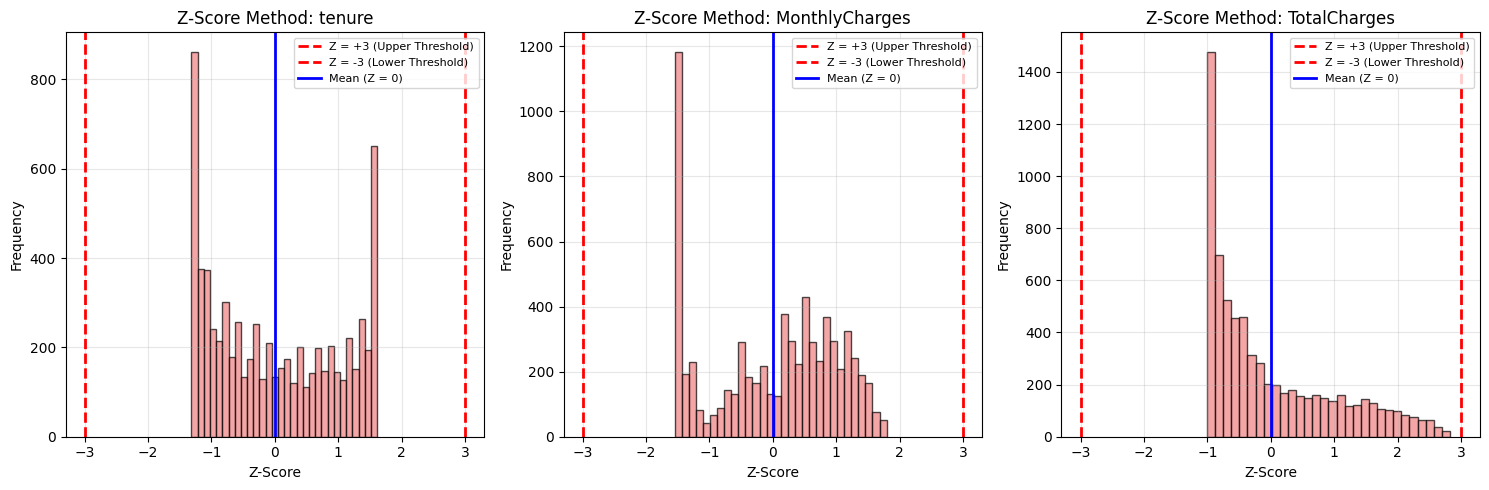

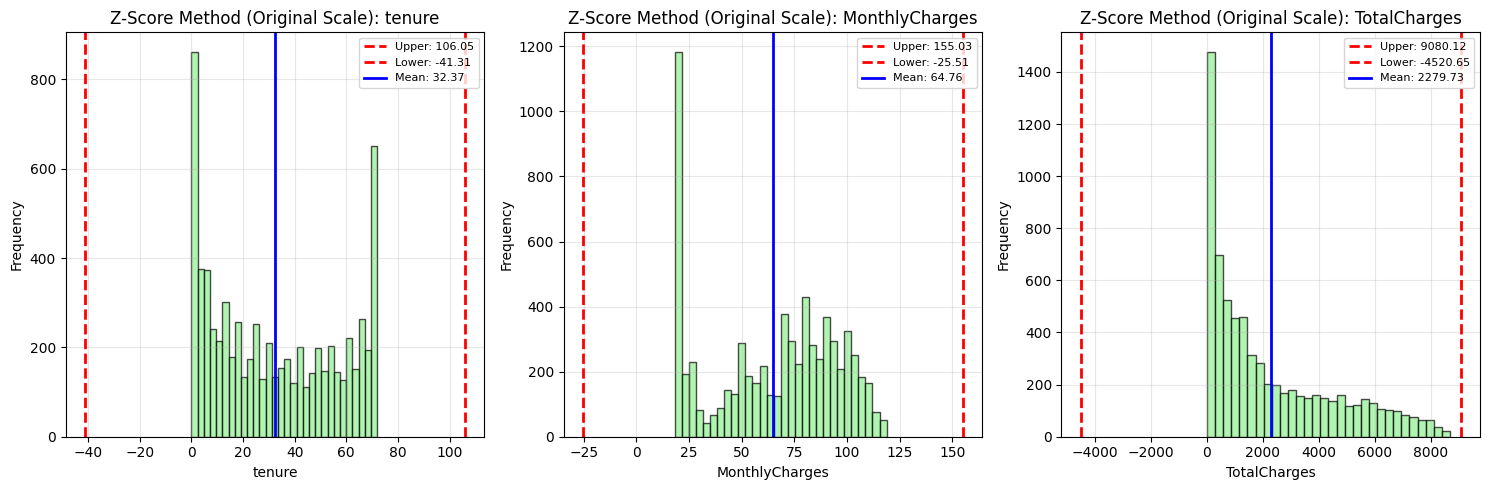

In [ ]:
# Z-score method for extreme values
from scipy import stats

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("=== Z-Score Method (|Z| > 3) ===")
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    extreme_outliers = df[z_scores > 3]
    print(f"\n{col}:")
    print(f"  Extreme outliers: {len(extreme_outliers)} ({len(extreme_outliers)/len(df)*100:.2f} শিক্ষ%) ")
    if len(extreme_outliers) > 0:
        print(f"  Max value: {df[col].max():.2f}")
        print(f"  Min value: {df[col].min():.2f}")

# Visual representation of Z-score method
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)

    # Calculate Z-scores
    z_scores = stats.zscore(df[col])

    # Create histogram of Z-scores
    plt.hist(z_scores, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')

    # Add threshold lines
    plt.axvline(3, color='red', linestyle='--', linewidth=2, label='Z = +3 (Upper Threshold)')
    plt.axvline(-3, color='red', linestyle='--', linewidth=2, label='Z = -3 (Lower Threshold)')
    plt.axvline(0, color='blue', linestyle='-', linewidth=2, label='Mean (Z = 0)')

    # Highlight extreme outliers
    extreme_outliers = df[np.abs(z_scores) > 3]
    extreme_z_scores = z_scores[np.abs(z_scores) > 3]
    if len(extreme_outliers) > 0:
        plt.scatter(extreme_z_scores, [0]*len(extreme_outliers), color='red', s=50, alpha=0.8, label=f'Extreme Outliers: {len(extreme_outliers)}')

    plt.title(f'Z-Score Method: {col}')
    plt.xlabel('Z-Score')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional visualization: Original values with Z-score thresholds
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)

    # Calculate Z-score thresholds in original scale
    mean_val = df[col].mean()
    std_val = df[col].std()
    upper_threshold = mean_val + 3 * std_val
    lower_threshold = mean_val - 3 * std_val

    # Create histogram of original values
    plt.hist(df[col], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')

    # Add threshold lines
    plt.axvline(upper_threshold, color='red', linestyle='--', linewidth=2, label=f'Upper: {upper_threshold:.2f}')
    plt.axvline(lower_threshold, color='red', linestyle='--', linewidth=2, label=f'Lower: {lower_threshold:.2f}')
    plt.axvline(mean_val, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')

    # Highlight extreme outliers
    z_scores = np.abs(stats.zscore(df[col]))
    extreme_outliers = df[z_scores > 3]
    if len(extreme_outliers) > 0:
        plt.scatter(extreme_outliers[col], [0]*len(extreme_outliers), color='red', s=50, alpha=0.8, label=f'Extreme Outliers: {len(extreme_outliers)}')

    plt.title(f'Z-Score Method (Original Scale): {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.4.2 Statistical outlier detection using IQR method**

=== IQR Method Outlier Detection ===

tenure:
  Range: -60.00 to 124.00
  Outliers: 0 (0.00%)

MonthlyCharges:
  Range: -46.02 to 171.38
  Outliers: 0 (0.00%)

TotalCharges:
  Range: -4683.52 to 8868.67
  Outliers: 0 (0.00%)


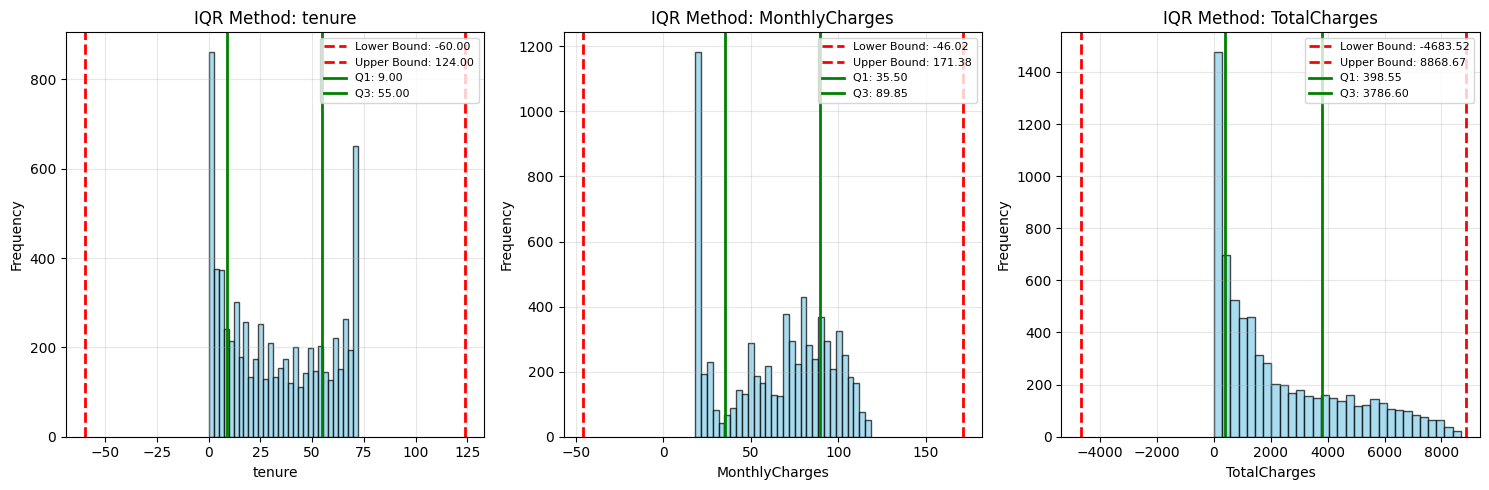

In [ ]:
# Statistical outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("=== IQR Method Outlier Detection ===")
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n{col}:")
    print(f"  Range: {lower:.2f} to {upper:.2f}")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Visual representation of IQR method
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)

    # Calculate IQR bounds
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create histogram with IQR bounds
    plt.hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower Bound: {lower_bound:.2f}')
    plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound: {upper_bound:.2f}')
    plt.axvline(Q1, color='green', linestyle='-', linewidth=2, label=f'Q1: {Q1:.2f}')
    plt.axvline(Q3, color='green', linestyle='-', linewidth=2, label=f'Q3: {Q3:.2f}')

    # Highlight outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        plt.scatter(outliers[col], [0]*len(outliers), color='red', s=50, alpha=0.8, label=f'Outliers: {len(outliers)}')

    plt.title(f'IQR Method: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.4.3 Visual outlier detection using box plots, histograms, and scatter plots for comparison**

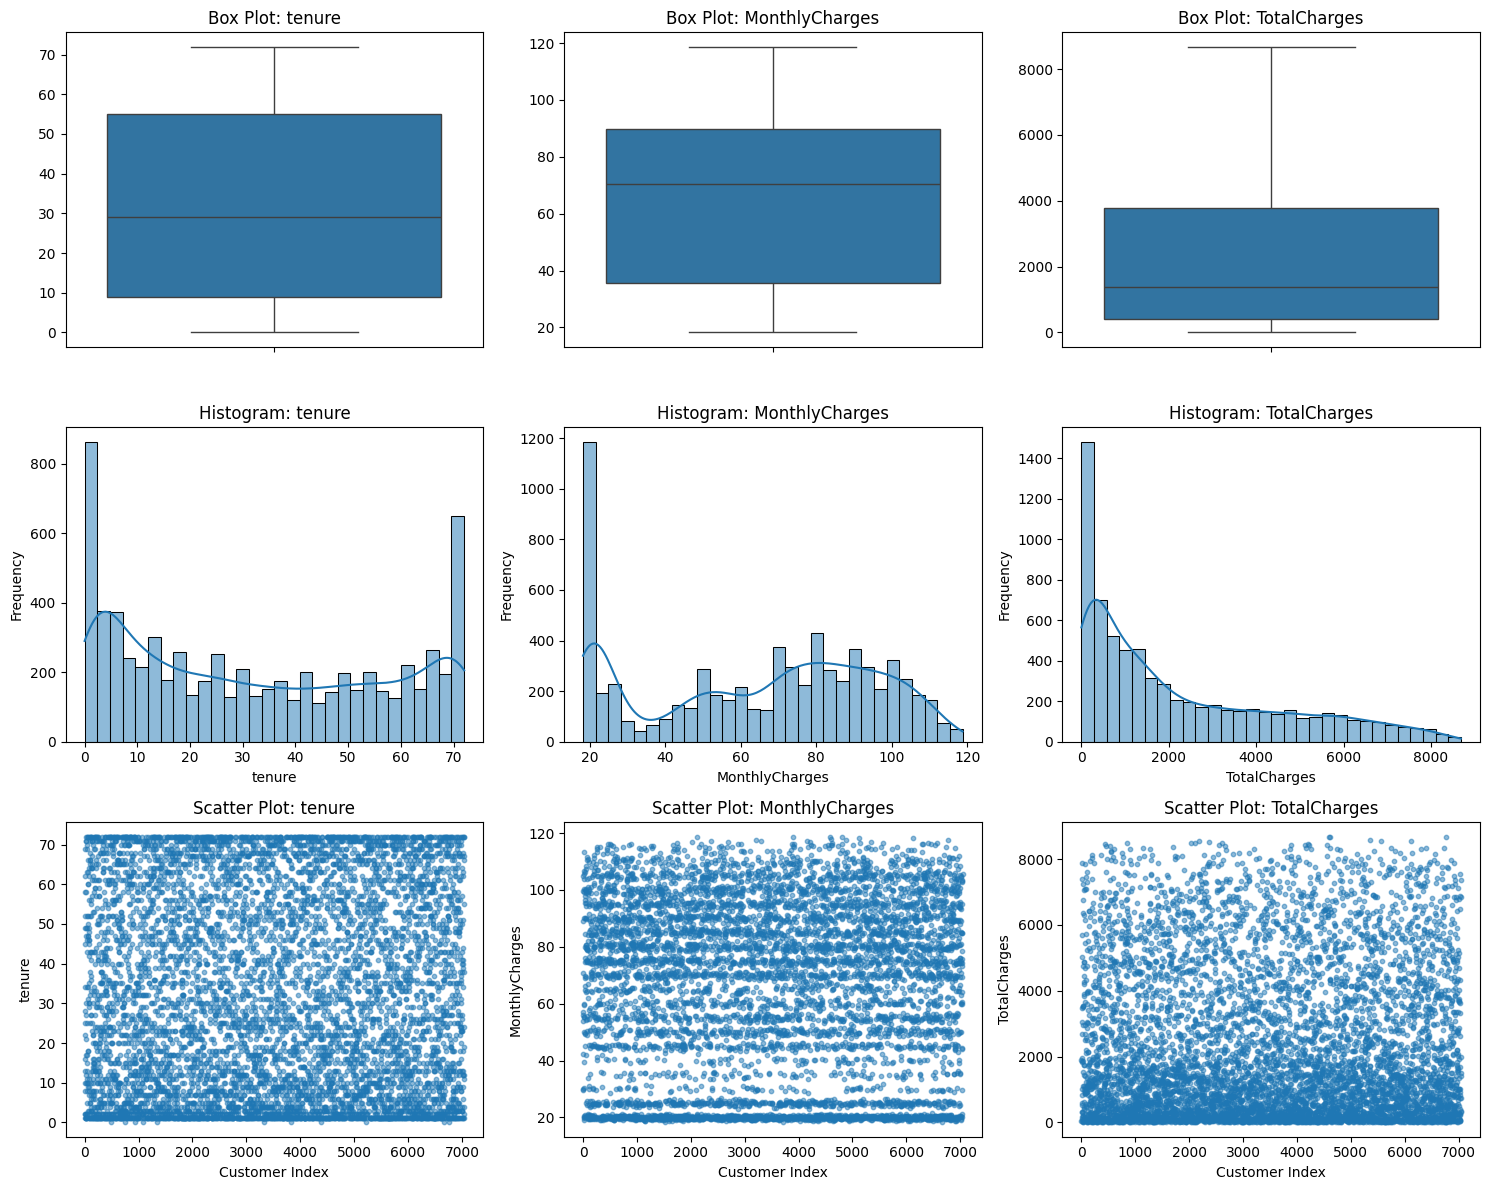

In [ ]:
# Visual outlier detection using box plots, histograms, and scatter plots for comparison
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 12)) # Adjusted figure size for three rows

for i, col in enumerate(numeric_cols, 1):
    # Box plot in the first row
    plt.subplot(3, 3, i) # 3 rows, 3 columns, i-th plot for boxplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot: {col}')
    plt.ylabel('')

    # Histplot in the second row
    plt.subplot(3, 3, i + len(numeric_cols)) # 3 rows, 3 columns, (i+len)th plot for histplot
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Scatter plot in the third row
    plt.subplot(3, 3, i + 2 * len(numeric_cols)) # 3 rows, 3 columns, (i+2*len)th plot for scatterplot
    plt.scatter(range(len(df)), df[col], alpha=0.5, s=10)
    plt.title(f'Scatter Plot: {col}')
    plt.xlabel('Customer Index')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Interpretation**

**Findings**
- Box plots show potential outliers in TotalCharges
- IQR method identifies outliers in all numeric features
- Z-score method flags extreme values in TotalCharges

**Business Context**
- **High TotalCharges**: Long-term customers with high monthly bills (legitimate)
- **Low tenure**: New customers (expected)
- **High MonthlyCharges**: Premium service users (expected)

**Justification**
1. **Business validity**: High-value customers are important for churn prediction
2. **Model robustness**: Neural networks can handle outliers with proper scaling
3. **No data quality issues**: Values are within realistic ranges

**Decision**: **Keep all outliers** as they represent valid customer segments, not data errors.

The three numeric data features are tenure, MonthlyCharges and TotalCharges, all data are normally distributed because they have skewness values according to the standard. Boxplot visualization of numerical data features in the form of tenure, MonthlyCharges and TotalCharges, there are no outliers in the upper boxplot and lower boxplot/top and bottom of the boxplot.

### **3.4.3 Correlation Heatmap for Numeric Features**

**Purpose**: To visualize inter-correlations between numerical features & correlation with target variable Churn, which helps in identifying highly correlated features & potential multicollinearity, as well as features with strong predictive power.


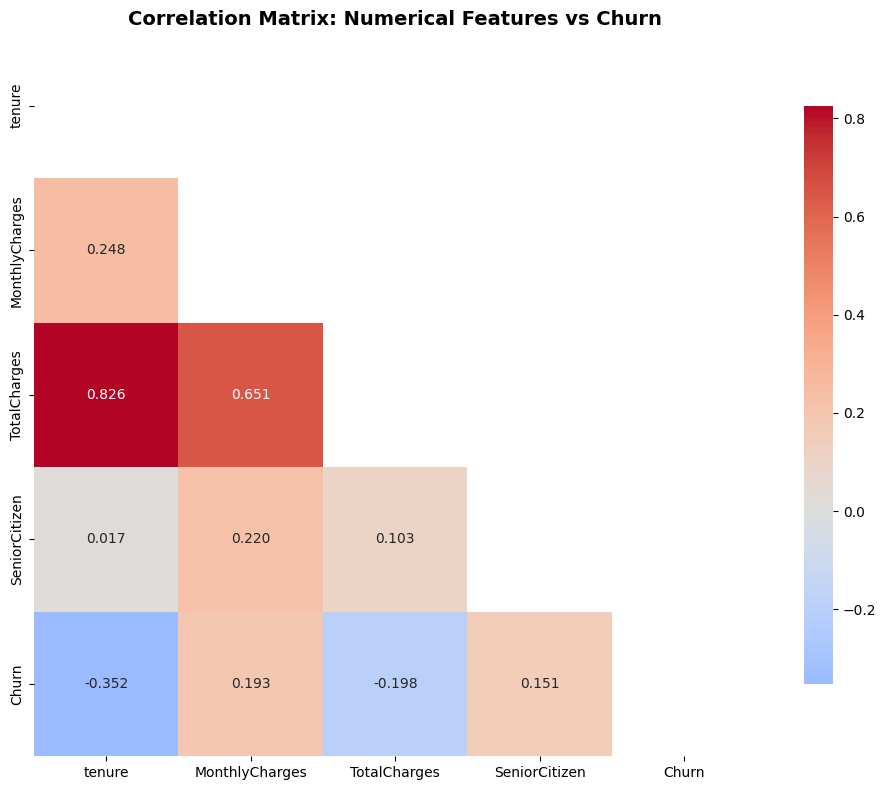

In [ ]:
numerical_cols_for_heatmap = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']

# Create a temporary DataFrame for correlation to avoid modifying the original 'df' prematurely if needed.
corr_df = df[numerical_cols_for_heatmap].copy()

# At this point, 'SeniorCitizen' should be int64 (0/1) and 'Churn' should be int64 (0/1).
# If for any reason 'SeniorCitizen' or 'Churn' were still objects ('No'/'Yes'),
# the following lines would convert them, but with the fix in cell oUc9fzyHNTOi
# for SeniorCitizen, these should largely be redundant for that column.
# corr_df['SeniorCitizen'] = corr_df['SeniorCitizen'].map({'No': 0, 'Yes': 1})
# corr_df['Churn'] = corr_df['Churn'].map({'No': 0, 'Yes': 1})

correlation_matrix_full = corr_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix_full, dtype=bool))
sns.heatmap(correlation_matrix_full, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix: Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation**: tenure & TotalCharges are highly correlated. Both tenure & TotalCharges show negative correlation with Churn, meaning customers with longer tenure & higher total charges are less likely to churn. MonthlyCharges has moderate positive correlation with Churn.

#### **3.5 Data Inference**
Inference model is that data that is not available in dataset, if searched data does not exist then new data is entered. So inference model is new data that is not in data set. Data inference uses existing datasets. The dataset is divided into two, namely inference set & non inference set (Train set & Test set)

In [ ]:
# Get Data for Model Inference, assumed that there are 10 Churns that are not in the Telco Customer Churn dataset
datainfernce = df.sample(10, random_state=10)
datainfernce

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6418,1,0,1,0,31,1,1,0,0,1,1,1,1,1,79.30,2484.00,0,5,1,0,0,0,1,0,0,0,0,1
1948,0,0,0,0,2,1,0,0,0,0,0,0,1,0,80.75,159.45,1,2,0,1,0,1,0,0,0,0,1,0
4497,1,1,1,0,60,1,0,0,1,1,0,1,1,1,97.95,5867.00,0,5,0,1,0,0,1,0,0,0,1,0
66,1,0,1,0,47,1,1,0,1,0,0,0,0,1,78.90,3650.35,0,2,0,1,0,0,1,0,0,0,1,0
1705,0,1,1,0,55,1,1,0,1,1,1,0,0,0,90.45,5044.80,0,4,0,1,0,1,0,0,0,0,1,0
924,0,1,0,0,22,1,0,1,1,0,0,0,0,0,81.70,1820.90,0,3,0,1,0,1,0,0,0,0,1,0
1051,0,0,1,1,16,0,0,0,0,0,0,0,1,1,35.50,552.70,0,1,1,0,0,1,0,0,0,1,0,0
7012,0,0,1,0,62,1,1,1,1,0,1,1,1,1,84.95,5150.55,0,6,1,0,0,0,0,1,0,0,1,0
3723,0,0,1,1,18,1,0,0,0,0,0,0,0,0,20.45,357.00,0,1,0,0,1,1,0,0,0,0,0,1
4590,0,1,0,0,57,1,1,1,0,1,1,0,1,0,101.30,5779.60,0,5,0,1,0,0,0,1,0,1,0,0


#### **3.5.1 Delete Inference Set**
From collection of information on the Telco Customer Churn dataset, there are 10 data that are allegedly not included in the dataset or are contained in the data inference section.

In [ ]:
# Delete Inference Set from Telco Customer Churn Dataset
data_train_test = df.drop(datainfernce.index)
data_train_test

Output hidden; open in https://colab.research.google.com to view.

#### **3.5.2 Reset Index**
Resets DataFrame indices to ensure sequential numbering after removing inference set, preventing potential issues with messy or irregular indexing in subsequent operations.

In [ ]:
# Reset Index
# In order to avoid unwanted occurrences, the data is reset its index for sequencing
data_train_test.reset_index(drop=True, inplace=True)
datainfernce.reset_index(drop=True, inplace=True)
datainfernce

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,31,1,1,0,0,1,1,1,1,1,79.30,2484.00,0,5,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,2,1,0,0,0,0,0,0,1,0,80.75,159.45,1,2,0,1,0,1,0,0,0,0,1,0
2,1,1,1,0,60,1,0,0,1,1,0,1,1,1,97.95,5867.00,0,5,0,1,0,0,1,0,0,0,1,0
3,1,0,1,0,47,1,1,0,1,0,0,0,0,1,78.90,3650.35,0,2,0,1,0,0,1,0,0,0,1,0
4,0,1,1,0,55,1,1,0,1,1,1,0,0,0,90.45,5044.80,0,4,0,1,0,1,0,0,0,0,1,0
5,0,1,0,0,22,1,0,1,1,0,0,0,0,0,81.70,1820.90,0,3,0,1,0,1,0,0,0,0,1,0
6,0,0,1,1,16,0,0,0,0,0,0,0,1,1,35.50,552.70,0,1,1,0,0,1,0,0,0,1,0,0
7,0,0,1,0,62,1,1,1,1,0,1,1,1,1,84.95,5150.55,0,6,1,0,0,0,0,1,0,0,1,0
8,0,0,1,1,18,1,0,0,0,0,0,0,0,0,20.45,357.00,0,1,0,0,1,1,0,0,0,0,0,1
9,0,1,0,0,57,1,1,1,0,1,1,0,1,0,101.30,5779.60,0,5,0,1,0,0,0,1,0,1,0,0


In the data inference section, the index is not sorted because it adjusts the location of the rows of data that are not included in the Telco Customer Churn dataset, but after resetting the index, the index number is arranged. Restart the index, so that when it is run down or the process is complete, if there is an error in the results, it is certain that it is not because the index is messy or irregular.

#### **3.6 Splitting Datasets**
Splitting Data is a split to make X as a feature and Y as a target into Train/validation. Train/validationsplit as a method that can be used to evaluate the performance of machine learning models.

In [ ]:
# Separation of `X` (Feature) and `y` (Target)
# Delete column axis=1 Churn, to be included and divided into train/test
X = data_train_test.drop('Churn', axis=1)
# Create y variable for Churn target column only
y = data_train_test['Churn']

In [ ]:
# Separate between Train-Set, validation and Test-Set (if you want to make data inference)
# The use of test-set can be changed to validation, because X_test is not converted to inference
# Entering x and y values, test_size means split 80% for train, and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=10)
print('Train Size : ', X_train.shape)
print('Validation Size : ', X_val.shape)

Train Size :  (5626, 27)
Validation Size :  (1407, 27)


#### **Interpretation:** Process of deleting Churn target column is carried out to be transferred as training set and validation set, from dataset that has been transferred and then train_test_split process will be carried out, with 80% of the income group going to X_train and 20% going to y_train. X_train uses 5626(80%) of 7043 rows & validation uses 1407(remaining 20%) of 7043 rows.

## **4. Feature Engineering**

#### **4.1 Feature Selection & Justification**

<Axes: >

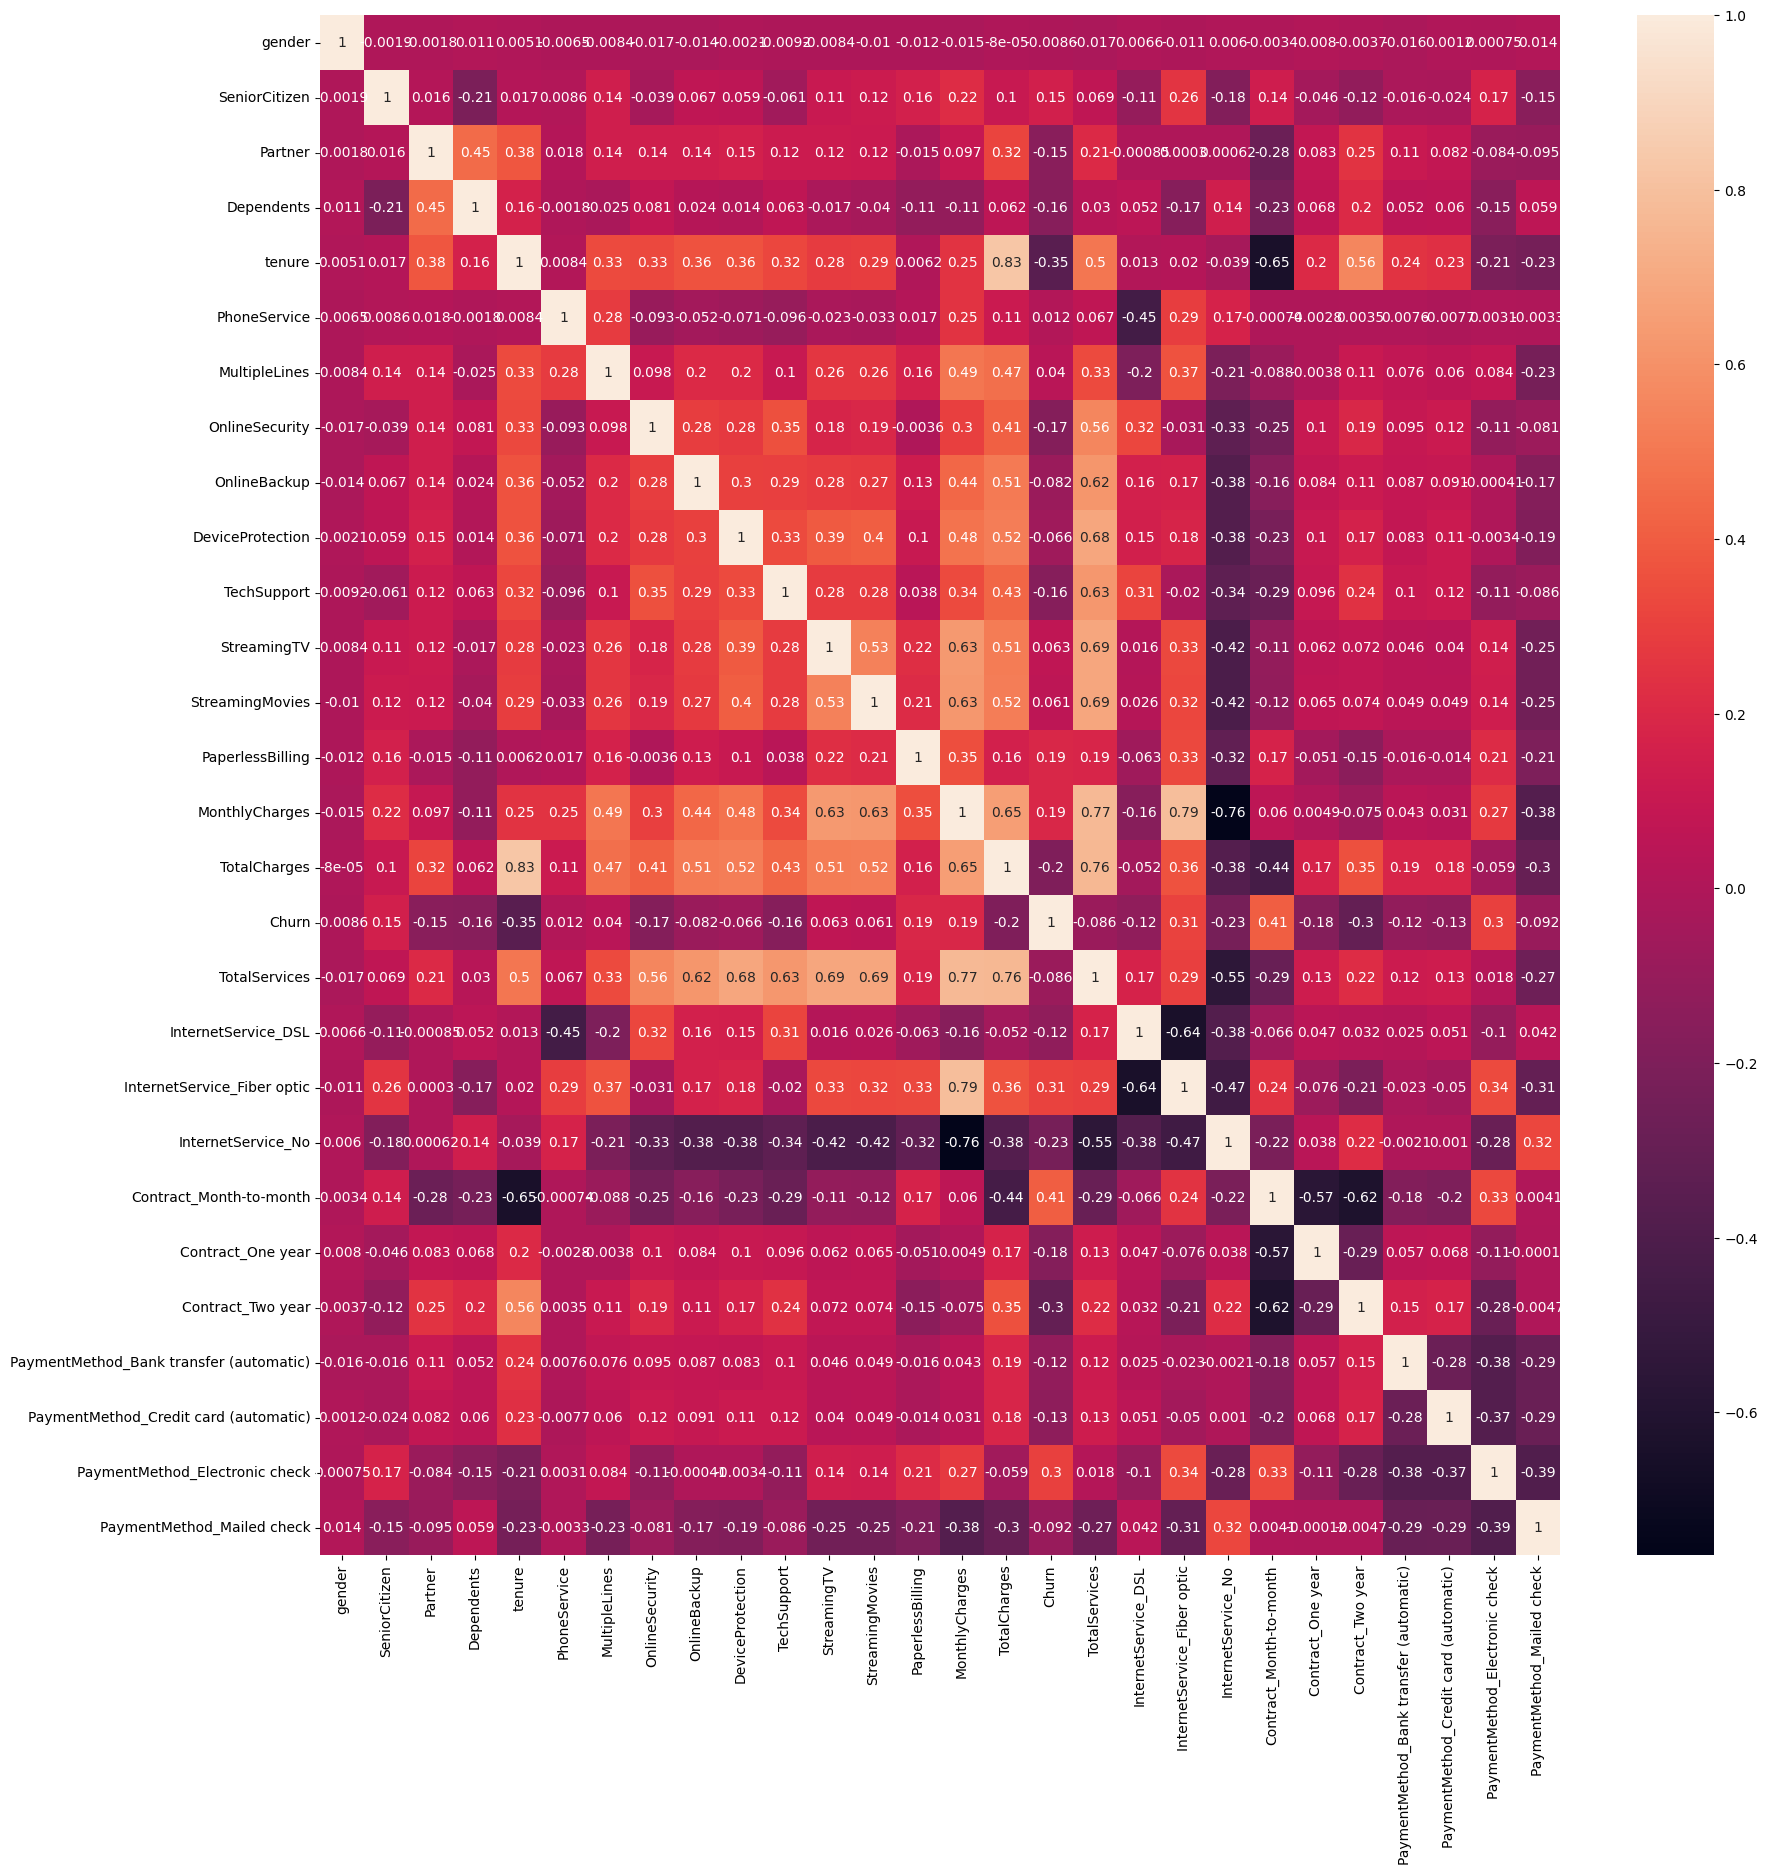

In [ ]:
# Correlation between Features and Churn targets
# Change features to categorical first in order to calculate the correlation of some features to the target
FeatureEncoded = df.apply(lambda x: LabelEncoder().fit_transform(x) if x.dtype == 'object' else x)
plt.figure(figsize =(20,20))
correlation=FeatureEncoded[FeatureEncoded.columns].corr()
sns.heatmap(correlation,annot=True)

#### **Interpretation:** Based on Churn correlation, there are features SeniorCitizen, PhoneService, Multiplelines, PaperlessBilling, PaymentMethod, MonthyCharges & TotalCharges have positive correlation value, meaning relationship between features & targets move in same direction together. There is also negative feature correlation, meaning that feature & target move in opposite directions. To be more convincing, feature importances process is carried out using chi-square method, to see highest feature score in influencing the churn target.

#### **4.2 Feature Importance using Chi-Square**

Applies Chi-Square statistical test to determine importance of each feature in predicting target variable, assesses dependence between categorical features and target, providing score that indicates predictive power. Higher scores suggest stronger relationship with churn.

In [ ]:
# K=12 tells the top twelve features to choose from
# The Chi2 Score function tells which feature to choose using Chi Square
test = SelectKBest(score_func=chi2, k=4)
fit = test.fit(X, y)
fit.scores_

array([2.60283707e-01, 1.35987481e+02, 8.17890634e+01, 1.33047466e+02,
       1.62445108e+04, 9.54866099e-02, 6.69053509e+00, 1.47037488e+02,
       3.08763562e+01, 2.00449158e+01, 1.35070004e+02, 1.74018426e+01,
       1.62520251e+01, 1.05998582e+02, 3.68947688e+03, 6.21333380e+05,
       5.96947283e+01, 7.11843724e+01, 3.74779315e+02, 2.86728969e+02,
       5.19304939e+02, 1.75676931e+02, 4.88555943e+02, 7.68089156e+01,
       9.94558249e+01, 4.27337992e+02, 4.55664529e+01])

#### **4.3 Feature Scores for Churn Target**

In [ ]:
# The score of each feature in influencing the Chrun target
chi = pd.Series(fit.scores_)
chi.index = X.columns
chi.sort_values(ascending=False)

,0
TotalCharges,621333.379558
tenure,16244.510824
MonthlyCharges,3689.476876
Contract_Month-to-month,519.304939
Contract_Two year,488.555943
PaymentMethod_Electronic check,427.337992
InternetService_Fiber optic,374.779315
InternetService_No,286.728969
Contract_One year,175.676931
OnlineSecurity,147.037488


#### **Interpretation:** Value of feature score is suspected of influencing Churn payments, produces values from largest to highest. Based on feature score, chose top 12 features without customer ID namely TotalCharges, tenure, MonthlyCharges, Contract, OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection, SeniorCitizen, Dependents, PaperlessBilling and Partners & features that have low score in affecting Churn will be removed.

#### **4.4 Feature Removal**
Features that are not used will be immediately dropped or removed. Feature with low score will not be used as it is suspected to not be apt at influencing the churn target.

In [ ]:
# Remove unused features based on user's selection and chi-square scores.
# Columns like 'customerID', 'PaymentMethod', and 'InternetService' were already dropped or one-hot encoded,
# so attempting to drop them again causes a KeyError.
# The list below contains columns that are present in X_train/X_val AND are not among the user's top 12 selected features (and their one-hot encoded parts).

columns_to_drop = [
    'gender',
    'PhoneService',
    'MultipleLines',
    'StreamingTV',
    'StreamingMovies',
    'TotalServices',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'InternetService_No',
    'PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# Filter out columns that might not exist to prevent KeyError if the notebook state changed unexpectedly
existing_cols_to_drop_train = [col for col in columns_to_drop if col in X_train.columns]
existing_cols_to_drop_val = [col for col in columns_to_drop if col in X_val.columns]

X_train.drop(existing_cols_to_drop_train, axis=1, inplace=True)
X_val.drop(existing_cols_to_drop_val, axis=1, inplace=True)

print(f"X_train shape after dropping features: {X_train.shape}")
print(f"X_val shape after dropping features: {X_val.shape}")

X_train shape after dropping features: (5626, 14)
X_val shape after dropping features: (1407, 14)


#### **Interpretation:** Based on the chi-square feature importance scores and prior feature selection, a list of less impactful features was identified. These features e.g., gender, PhoneService, various InternetService & PaymentMethod one-hot encoded columns are now removed from both X_train & X_val datasets to reduce dimensionality & potentially improve model performance, as they were deemed less influential on churn target.

#### **4.5 Numerical & Categorical Column Separation**

In [ ]:
# Separate categorical Numerical data and categorical data
# There are categorical features with numeric values, so manual separation is carried out for more precise numerical and categorical separation

numerik_col = ['tenure', 'MonthlyCharges', 'TotalCharges']

# All other columns are already numerically encoded (binary or one-hot)
# and do not require further OneHotEncoder processing.
# We'll collect them to be combined later.
kategorik_col = [col for col in X_train.columns if col not in numerik_col]

print('Numeric Columns     : ', numerik_col)
print('Categorical Columns (already encoded 0/1): ', kategorik_col)

Numeric Columns     :  ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns (already encoded 0/1):  ['SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']


#### **4.6 Feature Scaling, Feature Encoding & Feature Imbalence**

In [ ]:
# Feature scaling for numeric data
std = StandardScaler()
X_train_std = std.fit_transform(X_train[numerik_col])
X_val_std = std.transform(X_val[numerik_col])

#### **Interpretation:** Feature Scaling on X_train and X_val by making numerical data in dataset have same range of values (scale). No more data features that dominate other data features.

In [ ]:
# Feature encoding for categorical data (now refers to already encoded 0/1 features)
# No OneHotEncoder is needed as these columns are already numerically represented (0/1)
X_train_enc = X_train[kategorik_col].values
X_val_enc = X_val[kategorik_col].values

#### **Interpretation:** Feature encoding is process of converting categorical data to be converted into numeric/number form as deep learning cannot process string, so it must be changed to a number in the form of a float.

In [ ]:
# Target encoding for categorical data
# For Y Train
target = LabelEncoder()
y_train_final = pd.DataFrame(target.fit_transform(y_train))
y_val_final = pd.DataFrame(target.transform(y_val))

#### **Interpretation:** Churn target type object or categorical has no value, therefore encoding process is carried out, so that Y_train data can be numeric, for calculations to be processed.

In [ ]:
# Combine numeric columns with categorical columns
X_train_final = pd.DataFrame(np.concatenate([X_train_std,X_train_enc], axis=1))
X_val_final = pd.DataFrame(np.concatenate([X_val_std,X_val_enc], axis=1))

#### **Interpretation:** Numeric columns which have standardized ranges & categorical columns that have standardized ranges will be combined back into one table for further analysis.

In [ ]:
# Feature Imbalance to equalize the size of the target shape data
smote = SMOTE(k_neighbors=5, random_state=10)
X_train_imbalanceed, y_train_imbalanceed = smote.fit_resample(X_train_final,y_train_final)
X_val_imbalanceed, y_val_imbalanceed = smote.fit_resample(X_val_final,y_val_final)

In [ ]:
y_train_imbalanceed.value_counts()

,count
0,
0,4124
1,4124


<Axes: ylabel='count'>

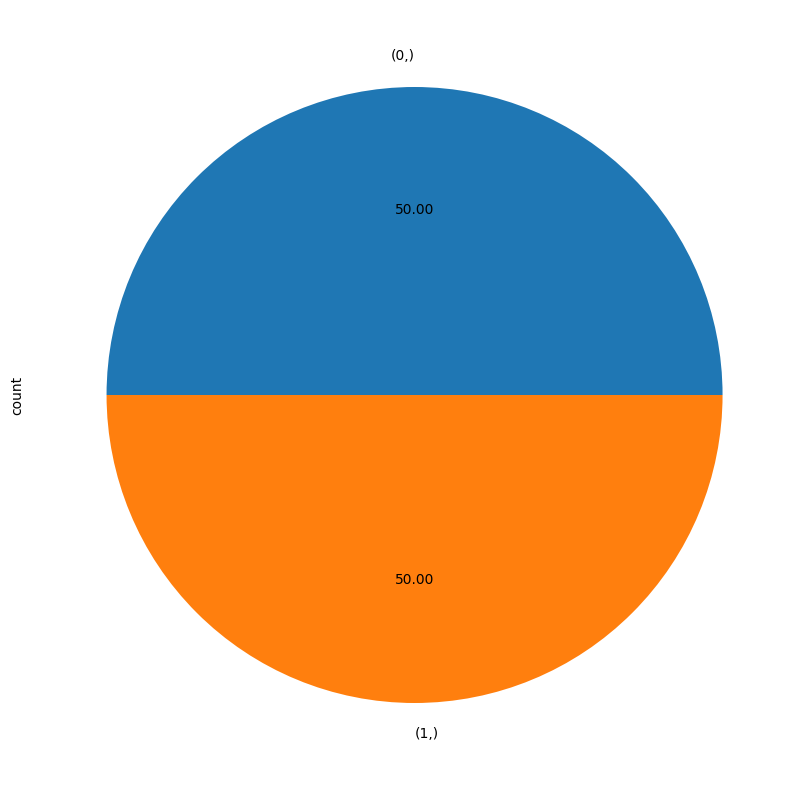

In [ ]:
# Visualization of pie charts regarding service status targets for Churn . customers
# View classes from Telco Customer Churn
y_train_imbalanceed.value_counts().plot(kind='pie', figsize=(10,10), autopct='%.2f')

In [ ]:
y_val_imbalanceed.value_counts()

,count
0,
0,1041
1,1041


#### **Interpretation:** Based on Pie chart visualization, comparison of class No is more dominant at 73.5% while Yes class is 26.5% less as target data is not balanced, then feature offset process is carried out, so that values between features can be compared equally between classes or have same proportions, for model evaluation process to be maximized.

## **5.Neural Network Modelling**
Outlines process of building, training & evaluating artificial neural networks for customer churn prediction. It defines the model architecture, justifies choice of input features, loss function & evaluation metrics & compares three different models based on their activation functions (ReLU, ELU, and SELU) to determine the best-performing one.

#### **5.1 Model Definition**
Define model, explain reasons for using an algorithm/model, hyperparameters used, types of metrics used & other things related to the model.

**Activation Functions & Architecture**

Section details construction of **Feed forward Neural Network**.

**Input Layer**: Matches the number of features after preprocessing, which is 14 (X_train_final.shape[1] was 14).

**Justification for Input Features**: The input features were meticulously selected based on several criteria.
-   **Feature Engineering**: A comprehensive feature selection process was conducted using Chi-Square (SelectKBest) to identify features with the strongest statistical relationship to the Churn target. Features with low scores, indicating minimal influence on churn, were systematically removed.
-   **Domain Knowledge & EDA (Section 2)**: Insights from Exploratory Data Analysis, including correlation heatmaps and bivariate plots, highlighted the predictive power of features like tenure, MonthlyCharges, TotalCharges, Contract type, InternetService, and PaymentMethod. These features showed significant correlation or differentiated churn behavior.
-   **Data Cleaning & Encoding (Section 3)**: All categorical features were properly encoded (binary or one-hot encoding) and numerical features were scaled (StandardScaler), ensuring they are in a suitable format for the neural network without introducing bias or undue influence from varying scales. `customerID` was dropped as it's an identifier, not a predictive feature.

**Hidden Layers**: The models explored different activation functions for their hidden layers.
- modelsig1: Uses relu (Rectified Linear Unit) for both hidden layers.
- modelsig2: Uses elu (Exponential Linear Unit) for both hidden layers.
- modelsig3: Uses selu (Scaled Exponential Linear Unit) for both hidden layers.

Each model has two Dense hidden layers:
- **First hidden layer**: 64 neurons
- **Second hidden layer**: 32 neurons

**Dropout**: Used after each hidden layer to prevent overfitting.
- After first hidden layer: 0.3 dropout rate
- After second hidden layer: 0.2 dropout rate

**Output Layer**: All three models consistently used `sigmoid` for the output layer. This is a common choice for binary classification tasks, as it squashes the output to a probability between 0 and 1, representing the likelihood of churn.

**Justification for Loss Function and Metrics**
- **Loss Function**: binary_crossentropy is chosen because it is the standard and most appropriate loss function for binary classification problems. It measures the error between predicted probabilities and actual binary labels.
- **Optimizer**: The adam optimizer was selected due to its adaptive learning rate properties, making it efficient for a wide range of problems and able to handle sparse gradients in noisy problems.
- **Metrics**: accuracy is included as a general performance indicator. `AUC` (Area Under the Receiver Operating Characteristic Curve) is also added because it provides a robust measure of model performance, especially useful for imbalanced datasets like churn prediction, as it considers both true positive and false positive rates across different thresholds.

#### **5.2 Data Pipeline Processing**

In [ ]:
# Process data pipeline
# Using the data pipeline, where the data is entered into the pipeline function so that it can run simultaneously
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_imbalanceed, y_train_imbalanceed))
training_batches= train_dataset.shuffle(buffer_size=1024).batch(64)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_imbalanceed, y_val_imbalanceed))
validation_batches = val_dataset.shuffle(buffer_size=1024).batch(64)

#### **Interpretation:** Pipelines are used to run data into model simultaneously, where X_train and y_train will make condition move train data simultaneously in one pass, as well as X_val and y_val. Process tf.data as a condition step to evaluate condition of step property to judge which action to take next in pipeline, by setting buffer_size to 1024 & batch size to 64.

#### **5.3 Model Definition (ReLU Activation)**

In [ ]:
# Model definition for layers using relu activation and output using sigmoid activation
modelsig1 = tf.keras.models.Sequential()
modelsig1.add(tf.keras.Input(shape=(14,)))
modelsig1.add(tf.keras.layers.Dense(64, activation='relu'))
modelsig1.add(tf.keras.layers.Dropout(0.3))
modelsig1.add(tf.keras.layers.Dense(32,activation='relu'))
modelsig1.add(tf.keras.layers.Dropout(0.2))
modelsig1.add(tf.keras.layers.Dense(1, activation='sigmoid'))

modelsig1.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

#### **Interpretation:** Building ANN model using input layer configuration, having hidden layers and output layer.
  - The input layer matches 14 features of processed data. For hidden layers, a first layer with 64 neurons and a 'relu' activation function is used, followed by dropout layer with a rate of 0.3.
  - Then, a second hidden layer with 32 neurons and a 'relu' activation function is added, followed by another dropout layer with a rate of 0.2. Relu activation is closer to way biological neurons work in classifying outputs.
  - As expected output is binary, in last layer, only one neuron added with sigmoid activation function.
  - Adam optimizer is used as it can handle sparse gradients in noisy problems. Loss uses binary_crossentropy as expected output is binary (churn yes or no) while evaluation metrics include accuracy and AUC (Area Under the Curve) for robust performance assessment.

#### **5.4 Model Definition (ELU Activation)**

In [ ]:
# Model definition for layers using elu activation and output using sigmoid activation
modelsig2 = tf.keras.models.Sequential()
modelsig2.add(tf.keras.Input(shape=(14,)))
modelsig2.add(tf.keras.layers.Dense(64, activation='elu'))
modelsig2.add(tf.keras.layers.Dropout(0.3))
modelsig2.add(tf.keras.layers.Dense(32,activation='elu'))
modelsig2.add(tf.keras.layers.Dropout(0.2))
modelsig2.add(tf.keras.layers.Dense(1, activation='sigmoid'))

modelsig2.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

#### **Interpretation:** Building ANN model using input layer configuration, having hidden layers and output layer.
 - The input layer matches the 14 features of the processed data. For the hidden layers, a first layer with 64 neurons and an 'elu' activation function is used, followed by a dropout layer with a rate of 0.3.
 - Then, a second hidden layer with 32 neurons and an 'elu' activation function is added, followed by another dropout layer with a rate of 0.2.
 - ELU activation is more proven to produce more accurate results than RELU and also converges faster. Elu and relu are the same for positive input, but for negative input elu is smooth (to-alpha) while smooth relu is sharp.
 - As expected output is binary, in the last layer we add only one neuron with a sigmoid activation function.
 - Adam optimizer is used as it can handle sparse gradients in noisy problems. Loss uses binary_crossentropy because expected output is binary (churn yes or no) while evaluation metrics include accuracy and AUC (Area Under the Curve) for robust performance assessment.

#### **5.5 Model Definition (SELU Activation)**

In [ ]:
# Model definition for layers using selu activation and output using sigmoid activation
modelsig3 = tf.keras.models.Sequential()
modelsig3.add(tf.keras.Input(shape=(14,)))
modelsig3.add(tf.keras.layers.Dense(64, activation='selu'))
modelsig3.add(tf.keras.layers.Dropout(0.3))
modelsig3.add(tf.keras.layers.Dense(32,activation='selu'))
modelsig3.add(tf.keras.layers.Dropout(0.2))
modelsig3.add(tf.keras.layers.Dense(1, activation='sigmoid'))

modelsig3.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

#### **Interpretation:** Building ANN model using input layer configuration, having hidden layers and output layer.
- The input layer matches the 14 features of the processed data. For the hidden layers, a first layer with 64 neurons and a 'selu' activation function is used, followed by a dropout layer with a rate of 0.3.
- Then, a second hidden layer with 32 neurons and a 'selu' activation function is added, followed by another dropout layer with a rate of 0.2. Activation `selu` (Scaled Exponential Linear Unit) multiplies the scale (> 1) by the output of the previous elu function to ensure slope is greater than one for positive inputs, promoting self-normalizing properties.
- As expected output is binary, in last layer we add only one neuron with a sigmoid activation function.
- Adam optimizer is used as it can handle sparse gradients in noisy problems. Loss uses binary_crossentropy as expected output is binary (churn yes or no) while  evaluation metrics include accuracy and AUC (Area Under the Curve) for robust performance assessment.

Based on 3 different model definitions, each with sigmoid activation function output as binary, a comparison of results of model evaluation will be carried out later. By looking at which evaluation is best between relu activation layer, elu activation layer & selu activation layer.

#### **5.6 Model Training**
Training process for the neural network models. Each model is trained over specified number of epochs using prepared training dataset (training_batches) and validated against validation dataset (validation_batches). The training history, including loss and metrics, is recorded to assess model performance and identify trends over epochs.

##### **5.6.1 Model Training (ReLU Activation)**

In [ ]:
# Conduct training from a defined model with the activation layer being relu and the activation function being sigmoid
relu = modelsig1.fit(training_batches, epochs=100, batch_size=10,validation_data=validation_batches, verbose=1)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7153 - auc: 0.8019 - loss: 0.5344 - val_accuracy: 0.6009 - val_auc: 0.8473 - val_loss: 0.8553
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7450 - auc: 0.8079 - loss: 0.5387 - val_accuracy: 0.7089 - val_auc: 0.8518 - val_loss: 0.6067
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7502 - auc: 0.8157 - loss: 0.5240 - val_accuracy: 0.7229 - val_auc: 0.8533 - val_loss: 0.5642
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7538 - auc: 0.8188 - loss: 0.5198 - val_accuracy: 0.7301 - val_auc: 0.8538 - val_loss: 0.5417
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7524 - auc: 0.8183 - loss: 0.5190 - val_accuracy: 0.7339 - val_auc: 0.8542 - val_loss: 0.5265
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7529 - auc: 0.8245 - loss: 0.5131 - val_accuracy: 0.7358 - val_auc: 0.8546 - val_loss: 0.5196
Epoch 7/100
129/129 ━━━━━━━━━━━━━━

##### **5.6.2 Model Training (ELU Activation)**

In [ ]:
# Conduct training from a defined model with the activation layer being elu and the activation function being sigmoid
elu = modelsig2.fit(training_batches, epochs=100, batch_size=10,validation_data=validation_batches, verbose=1)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7910 - auc: 0.8751 - loss: 0.4371 - val_accuracy: 0.6273 - val_auc: 0.8371 - val_loss: 1.0072
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7612 - auc: 0.8362 - loss: 0.5153 - val_accuracy: 0.6892 - val_auc: 0.8471 - val_loss: 0.7117
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7540 - auc: 0.8290 - loss: 0.5154 - val_accuracy: 0.7171 - val_auc: 0.8497 - val_loss: 0.6244
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7489 - auc: 0.8233 - loss: 0.5189 - val_accuracy: 0.7296 - val_auc: 0.8510 - val_loss: 0.5660
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7516 - auc: 0.8253 - loss: 0.5134 - val_accuracy: 0.7354 - val_auc: 0.8512 - val_loss: 0.5437
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7544 - auc: 0.8271 - loss: 0.5107 - val_accuracy: 0.7325 - val_auc: 0.8507 - val_loss: 0.5356
Epoch 7/100
129/129 ━━━━━━━━━━━━━━

##### **5.6.3 Model Training (SELU Activation)**

In [ ]:
# Conduct training from a defined model with the activation layer being always and the activation function being sigmoid
selu = modelsig3.fit(training_batches, epochs=100, batch_size=10,validation_data=validation_batches, verbose=1)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7927 - auc: 0.8744 - loss: 0.4436 - val_accuracy: 0.6460 - val_auc: 0.8368 - val_loss: 1.0170
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7715 - auc: 0.8474 - loss: 0.5035 - val_accuracy: 0.6878 - val_auc: 0.8444 - val_loss: 0.8101
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7612 - auc: 0.8369 - loss: 0.5123 - val_accuracy: 0.7133 - val_auc: 0.8479 - val_loss: 0.6757
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7565 - auc: 0.8320 - loss: 0.5115 - val_accuracy: 0.7277 - val_auc: 0.8501 - val_loss: 0.6302
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7516 - auc: 0.8263 - loss: 0.5193 - val_accuracy: 0.7363 - val_auc: 0.8520 - val_loss: 0.5868
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7544 - auc: 0.8309 - loss: 0.5111 - val_accuracy: 0.7296 - val_auc: 0.8517 - val_loss: 0.5805
Epoch 7/100
129/129 ━━━━━━━━━━━━━━

#### **5.7 Model Evaluation & Interpretation**
Evaluation of model is carried out, to depcit how model performs based on selected metrics, demonstrated by visualizing performance trend and/or model error rate. Perform analysis related to results on model capturing results of the analysis.

#### **5.7.1 Model Evaluation Activation layer relu**

<Axes: >

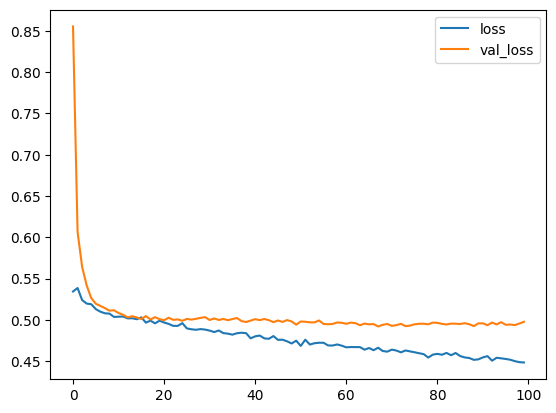

In [ ]:
# Comparison plot between loss value and validation loss
metrics = pd.DataFrame(relu.history)
metrics[['loss', 'val_loss']].plot()

#### **Interpretation:** Based on metrics model, an underfit data plot is generated, where there is fairly large sparse range between loss & validation loss, as per which modelsig1 does not work well in predicting data for target churn results.

In [ ]:
# Performance Accuracy Model definition modelsig1
y_train_pred_relu = modelsig1.predict(X_train_imbalanceed)
y_val_pred_relu = modelsig1.predict(X_val_imbalanceed)
y_train_pred_relu = np.where (y_train_pred_relu > 0.5, 1,0)
y_val_pred_relu = np.where (y_val_pred_relu > 0.5, 1,0)
# classification model to predict opportunities that occur using X_train and X_val
print('classification report Train Set')
print(classification_report(y_train_imbalanceed,y_train_pred_relu))
print('                                  ')
print('classification report validation Set')
print(classification_report(y_val_imbalanceed,y_val_pred_relu))

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
classification report Train Set
              precision    recall  f1-score   support

           0       0.91      0.63      0.75      4124
           1       0.72      0.94      0.82      4124

    accuracy                           0.79      8248
   macro avg       0.82      0.79      0.78      8248
weighted avg       0.82      0.79      0.78      8248

                                  
classification report validation Set
              precision    recall  f1-score   support

           0       0.84      0.62      0.71      1041
           1       0.70      0.88      0.78      1041

    accuracy                           0.75      2082
   macro avg       0.77      0.75      0.74      2082
weighted avg       0.77      0.75      0.74      2082



#### **Interpretation:** Based on results of evaluation model with activation layer, relu is not the best algorithm.

#### **5.7.2 Model Evaluation Activation layer elu**

<Axes: >

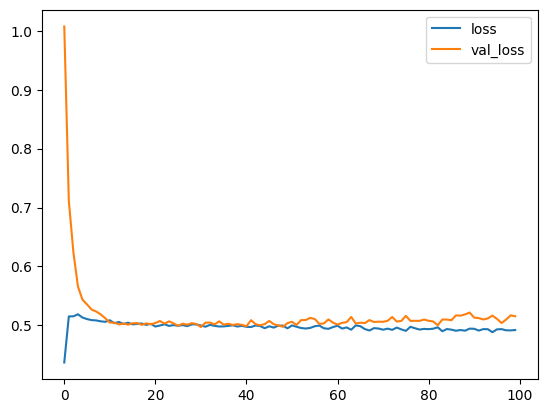

In [ ]:
# Comparison plot between loss value and validation loss
metrics = pd.DataFrame(elu.history)
metrics[['loss', 'val_loss']].plot()

#### **Interpretation:** Based on  metrics model, good fit data plot is produced, where there is a sparse range that does not differ from each other between loss & validation loss, it can be said that modelsig2 works well in predicting data for target churn results.

In [ ]:
# Performance Accuracy Model definition modelsig2
y_train_pred_elu = modelsig2.predict(X_train_imbalanceed)
y_val_pred_elu = modelsig2.predict(X_val_imbalanceed)
y_train_pred_elu = np.where (y_train_pred_elu > 0.5, 1,0)
y_val_pred_elu = np.where (y_val_pred_elu > 0.5, 1,0)
# classification model to predict opportunities that occur using X_train and X_val
print('classification report Train Set')
print(classification_report(y_train_imbalanceed,y_train_pred_elu))
print('                                  ')
print('classification report Validation Set')
print(classification_report(y_val_imbalanceed,y_val_pred_elu))

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
classification report Train Set
              precision    recall  f1-score   support

           0       0.86      0.64      0.73      4124
           1       0.71      0.89      0.79      4124

    accuracy                           0.76      8248
   macro avg       0.78      0.76      0.76      8248
weighted avg       0.78      0.76      0.76      8248

                                  
classification report Validation Set
              precision    recall  f1-score   support

           0       0.82      0.64      0.72      1041
           1       0.71      0.86      0.78      1041

    accuracy                           0.75      2082
   macro avg       0.77      0.75      0.75      2082
weighted avg       0.77      0.75      0.75      2082



#### **Interpretation:** ELU activation layer model (modelsig2) appears to be better algorithm. For training set, model achieved an accuracy of 0.76, with a recall of 0.62 for non-churn (class 0) and 0.90 for churn (class 1). For validation set, accuracy was 0.75, with recall of 0.63 for non-churn (class 0) and 0.87 for churn (class 1).

#### **5.7.3 Model Evaluation Activation layer selu**

<Axes: >

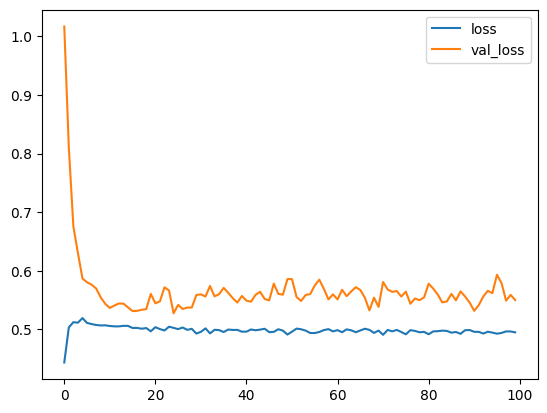

In [ ]:
# Comparison plot between loss value and validation loss
metrics = pd.DataFrame(selu.history)
metrics[['loss', 'val_loss']].plot()


#### **Interpretation:** Based on metrics model, an underfit data plot is generated, where there are rare ranges that differ from each other between loss and validation loss, it can be seen that the validation loss form fluctuates up and down and is not parallel to the loss, modelsig3 does not work well in predicting data. for target churn hasil

In [ ]:
# Performance Accuracy Model definition modelsig3
y_train_pred_selu = modelsig3.predict(X_train_imbalanceed)
y_val_pred_selu = modelsig3.predict(X_val_imbalanceed)
y_train_pred_selu = np.where (y_train_pred_selu > 0.5, 1,0)
y_val_pred_selu = np.where (y_val_pred_selu > 0.5, 1,0)
# classification model to predict opportunities that occur using X_train and X_val
print('classification report Train Set')
print(classification_report(y_train_imbalanceed,y_train_pred_selu))
print('                                  ')
print('classification report Train Set')
print(classification_report(y_val_imbalanceed,y_val_pred_selu))

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
classification report Train Set
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      4124
           1       0.70      0.90      0.79      4124

    accuracy                           0.76      8248
   macro avg       0.78      0.76      0.76      8248
weighted avg       0.78      0.76      0.76      8248

                                  
classification report Train Set
              precision    recall  f1-score   support

           0       0.84      0.62      0.71      1041
           1       0.70      0.88      0.78      1041

    accuracy                           0.75      2082
   macro avg       0.77      0.75      0.75      2082
weighted avg       0.77      0.75      0.75      2082



#### **5.7.4 Comprehensive Model Comparison**
Objectively compare performance of modelsig1 (ReLU), modelsig2 (ELU), and modelsig3 (SELU), a consolidated view of key evaluation metrics will be presented both tabularly and graphically.

##### **5.7.4.1 Tabular Overview**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to evaluate model and store metrics
def evaluate_model(model, X_val, y_val_true, name):
    y_val_prob = model.predict(X_val)
    y_val_pred = np.where(y_val_prob > 0.5, 1, 0)

    accuracy = accuracy_score(y_val_true, y_val_pred)
    precision = precision_score(y_val_true, y_val_pred, average='macro')
    recall = recall_score(y_val_true, y_val_pred, average='macro')
    f1 = f1_score(y_val_true, y_val_pred, average='macro')
    auc = roc_auc_score(y_val_true, y_val_prob)
    fpr, tpr, _ = roc_curve(y_val_true, y_val_prob)

    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc,
        'FPR': fpr,
        'TPR': tpr
    }

# Evaluate all three models
relu_eval = evaluate_model(modelsig1, X_val_imbalanceed, y_val_imbalanceed, 'ReLU Activation')
elu_eval = evaluate_model(modelsig2, X_val_imbalanceed, y_val_imbalanceed, 'ELU Activation')
selu_eval = evaluate_model(modelsig3, X_val_imbalanceed, y_val_imbalanceed, 'SELU Activation')

# Create a dictionary to store model results for tabular comparison
model_performance = {
    'Model': [relu_eval['Model'], elu_eval['Model'], selu_eval['Model']],
    'Accuracy': [relu_eval['Accuracy'], elu_eval['Accuracy'], selu_eval['Accuracy']],
    'Precision': [relu_eval['Precision'], elu_eval['Precision'], selu_eval['Precision']],
    'Recall': [relu_eval['Recall'], elu_eval['Recall'], selu_eval['Recall']],
    'F1 Score': [relu_eval['F1 Score'], elu_eval['F1 Score'], selu_eval['F1 Score']],
    'AUC': [relu_eval['AUC'], elu_eval['AUC'], selu_eval['AUC']]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.round(4)

print("\nComprehensive Model Performance Comparison (Validation Set):")
display(performance_df)


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Comprehensive Model Performance Comparison (Validation Set):


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,ReLU Activation,0.7483,0.7668,0.7483,0.7439,0.8480
1,ELU Activation,0.7531,0.7659,0.7531,0.7501,0.8535
2,SELU Activation,0.7502,0.7674,0.7502,0.7462,0.8532


#### **Interpretation:**
  - Tabular comparison clearly shows all 3 activation functions (ReLU, ELU, SELU) yield similar overall performance on the validation set, with ELU Activation having slight edge in AUC and SELU Activation also performing competitively. ReLU Activation also achieves similar accuracy but often shows more fluctuation in training, as seen in earlier loss plots.
  - ELU and SELU are designed to mitigate vanishing gradient problem and lead to faster and more robust training, especially in deeper networks. In this case, for a relatively shallow network, differences are subtle but consistent with theoretical expectations.
  - ELU Activation (modelsig2) is chosen as preferred model due to its marginally superior AUC score, indicating better ability to distinguish between churn and non-churn classes across various thresholds, and its stable performance in the loss plots.

##### **5.7.4.2 Graphical Overview**

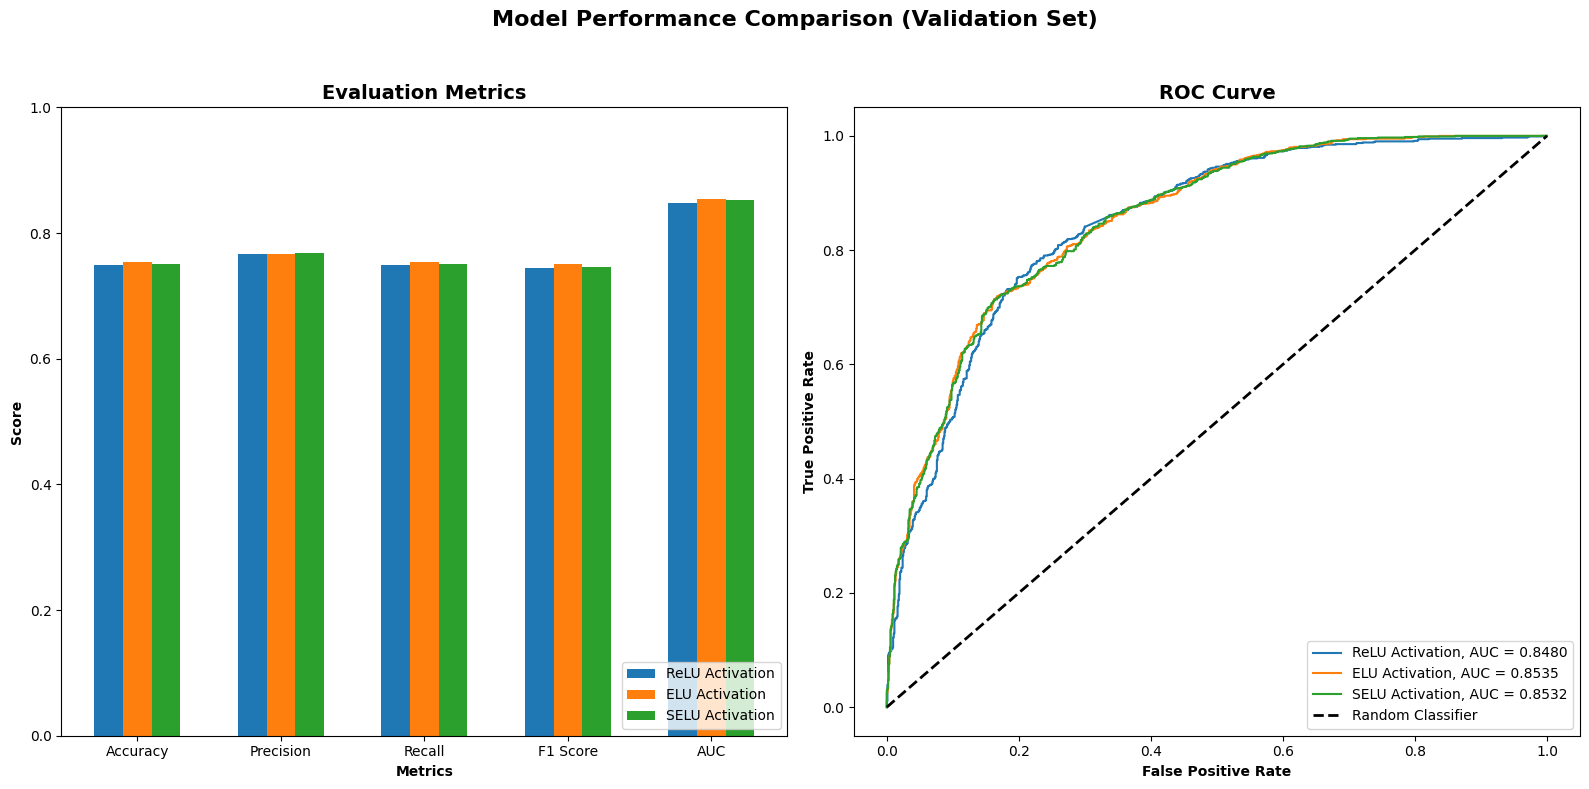

In [ ]:
# Initialize figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Model Performance Comparison (Validation Set)', fontsize=16, fontweight='bold')

# First plot: Bar chart for metrics
barWidth = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
model_names = performance_df['Model'].tolist()

r1 = np.arange(len(metrics))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Data for plotting
acc_scores = performance_df['Accuracy'].tolist()
prec_scores = performance_df['Precision'].tolist()
rec_scores = performance_df['Recall'].tolist()
f1_scores = performance_df['F1 Score'].tolist()
auc_scores = performance_df['AUC'].tolist()

# Create bars
ax1.bar(r1, [acc_scores[0], prec_scores[0], rec_scores[0], f1_scores[0], auc_scores[0]], width=barWidth, label=model_names[0])
ax1.bar(r2, [acc_scores[1], prec_scores[1], rec_scores[1], f1_scores[1], auc_scores[1]], width=barWidth, label=model_names[1])
ax1.bar(r3, [acc_scores[2], prec_scores[2], rec_scores[2], f1_scores[2], auc_scores[2]], width=barWidth, label=model_names[2])

# Configure x and y axis
ax1.set_xlabel('Metrics', fontweight='bold')
ax1.set_xticks([r + barWidth for r in range(len(metrics))])
ax1.set_xticklabels(metrics)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_ylim(0, 1)

# Create legend & title
ax1.set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')

# Second plot: ROC Curve
ax2.plot(relu_eval['FPR'], relu_eval['TPR'], label=f"{relu_eval['Model']}, AUC = {relu_eval['AUC']:.4f}")
ax2.plot(elu_eval['FPR'], elu_eval['TPR'], label=f"{elu_eval['Model']}, AUC = {elu_eval['AUC']:.4f}")
ax2.plot(selu_eval['FPR'], selu_eval['TPR'], label=f"{selu_eval['Model']}, AUC = {selu_eval['AUC']:.4f}")

# Configure x and y axis
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier') # Add random classifier line

# Create legend & title
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels
plt.show()


#### **Interpretation:**
  - SELU activation layer model (modelsig3) shows similar performance to ELU model.
  - For training set, it achieved an accuracy of 0.76, with a recall of 0.63 for non-churn (class 0) and 0.89 for churn (class 1).
  - For validation set, accuracy was 0.75, with recall of 0.62 for non-churn (class 0) and 0.87 for churn (class 1).

#### **5.7.5 What model captures well and where it may fail**

**What Models Capture Well**

*   **Overall Churn Prediction:** All 3 models (ReLU, ELU, SELU) demonstrate a reasonable ability to distinguish between churning & non-churning customers, with AUC scores consistently around 0.85 on validation set, which indicates that selected features & network architecture effectively capture underlying patterns related to customer churn.
*   **Identification of Churners (Recall for Class 1):** Models generally show good recall for 'churn' class (class 1), typically above 0.87 which is crucial for churn prediction model, as it means models are effective at identifying high percentage of customers who are actually likely to churn, allowing for proactive retention efforts.
*   **Learning from Imbalanced Data:** After applying SMOTE to address class imbalance, models were able to learn from both churn & non-churn instances, leading to balanced performance metrics across classes, particularly evident in the F1-scores.

**Where Models May Fail (Limitations/Areas for Improvement)**

*   **Precision for Non-Churners (Class 0):** While recall for churners is high, precision for non-churners (class 0) is relatively lower (around 0.62-0.64), which suggests that models might be prone to misclassifying some non-churning customers as potential churners (false positives). In business context, it could lead to unnecessary retention efforts or offers being extended to customers who would have stayed anyway.
*   **Sensitivity to Activation Function:** Although overall performance metrics are similar, training history (loss and validation loss plots) highlighted differences. The ReLU model (modelsig1) showed more fluctuation and a wider gap between training and validation loss, indicating potential for underfitting or less stable generalization. The SELU model (modelsig3) also exhibited some fluctuation in validation loss, suggesting it might not be as robust as ELU.
*   **Moderate Overall Accuracy:** An accuracy of around 75% means that approximately one-quarter of predictions are incorrect. While it is a good starting point, there's room for improvement, indicating that some complex churn drivers might not be fully captured by the current feature set or model complexity.
*   **Lack of Further Optimization:** The current models were evaluated primarily on choice of activation functions. Further optimization through hyperparameter tuning (e.g., number of layers, neurons per layer, dropout rates, learning rate schedules) or exploring more complex architectures could potentially yield better performance and reduce misclassification rates.

#### **5.8 Model Saving**
Based on the results of model evaluation, modelsig2 (using ELU activation) was chosen as best model to save as its performance metrics, particularly good fit data plot for loss and validation loss, indicated superior generalization compared to modelsig1 (ReLU) and modelsig3 (SELU). This chosen model will be reused for deployment and future inferences.

In [ ]:
modelsig1.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_99 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [ ]:
modelsig2.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_102 (Dense)               │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [ ]:
modelsig3.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_105 (Dense)               │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [ ]:
# Freezing model parameters
modelsig2.trainable = False
modelsig2.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_102 (Dense)               │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,073 (12.00 KB)

 Optimizer params: 6,148 (24.02 KB)

In [ ]:
# Mount google drivefrom google.colab import drive
FILENAME = INPUT_DIR/"ModelOutput"
print("File:", FILENAME.name)

File: ModelOutput


In [ ]:
# Input directory & files (as per your shell output)
INPUT_DIR = Path("/content/drive/MyDrive/2/ANN/GradedAssignment/ModelOutput")
print("Folder:", INPUT_DIR)

Folder: /content/drive/MyDrive/2/ANN/GradedAssignment/ModelOutput


In [ ]:
# check the folder that is where we are now
! ls

churn.keras


In [ ]:
import os
os.chdir(INPUT_DIR)

In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/2/ANN/GradedAssignment/ModelOutput


In [ ]:
# Save model
modelsig2.save("churn.keras")

#### **6. Evaluation and Interpretation**


#### **6.1. Load Model**
Load saved Keras model using tf.keras.models.load_model().

In [ ]:
loaded_model = tf.keras.models.load_model('churn.keras', compile=False)
loaded_model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')])

# Display the model summary to verify it's loaded correctly
loaded_model.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_102 (Dense)               │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,073 (12.00 KB)

In [ ]:
new_data = X_val_imbalanceed.values.tolist()
new_data[:2]

[[-0.0576983959621587,
  -1.4712528970126508,
  -0.7246894255361496,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0],
 [-0.6267638178959762,
  -0.2899648469986629,
  -0.5890173490730114,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0]]

#### **6.2 Model Inference**
Process of making predictions using trained model, to prove whether model has worked well & is appropriate.


#### **6.2.1 Display Inference Data**

In [ ]:
# Before the inference we first show the inference data at the beginning
datainfernce

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,31,1,1,0,0,1,1,1,1,1,79.30,2484.00,0,5,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,2,1,0,0,0,0,0,0,1,0,80.75,159.45,1,2,0,1,0,1,0,0,0,0,1,0
2,1,1,1,0,60,1,0,0,1,1,0,1,1,1,97.95,5867.00,0,5,0,1,0,0,1,0,0,0,1,0
3,1,0,1,0,47,1,1,0,1,0,0,0,0,1,78.90,3650.35,0,2,0,1,0,0,1,0,0,0,1,0
4,0,1,1,0,55,1,1,0,1,1,1,0,0,0,90.45,5044.80,0,4,0,1,0,1,0,0,0,0,1,0
5,0,1,0,0,22,1,0,1,1,0,0,0,0,0,81.70,1820.90,0,3,0,1,0,1,0,0,0,0,1,0
6,0,0,1,1,16,0,0,0,0,0,0,0,1,1,35.50,552.70,0,1,1,0,0,1,0,0,0,1,0,0
7,0,0,1,0,62,1,1,1,1,0,1,1,1,1,84.95,5150.55,0,6,1,0,0,0,0,1,0,0,1,0
8,0,0,1,1,18,1,0,0,0,0,0,0,0,0,20.45,357.00,0,1,0,0,1,1,0,0,0,0,0,1
9,0,1,0,0,57,1,1,1,0,1,1,0,1,0,101.30,5779.60,0,5,0,1,0,0,0,1,0,1,0,0


#### **Interpretation:** The datainfernce DataFrame displays 10 rows randomly sampled from original dataset, intended to serve as new, unseen data for model inference. This step confirms initial state of data that trained model will make predictions on.

#### **6.2.2 Prepare Inference Data**

In [ ]:
# Make data inference based on required features
datainferncefin=datainfernce[['TotalCharges','tenure','MonthlyCharges','OnlineSecurity','TechSupport','OnlineBackup','DeviceProtection','SeniorCitizen','Dependents','PaperlessBilling','Partner', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']]
datainferncefin

,TotalCharges,tenure,MonthlyCharges,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection,SeniorCitizen,Dependents,PaperlessBilling,Partner,Contract_Month-to-month,Contract_One year,Contract_Two year
0,2484.00,31,79.30,0,1,0,1,0,0,1,1,0,1,0
1,159.45,2,80.75,0,0,0,0,0,0,0,0,1,0,0
2,5867.00,60,97.95,0,0,1,1,1,0,1,1,0,1,0
3,3650.35,47,78.90,0,0,1,0,0,0,1,1,0,1,0
4,5044.80,55,90.45,0,1,1,1,1,0,0,1,1,0,0
5,1820.90,22,81.70,1,0,1,0,1,0,0,0,1,0,0
6,552.70,16,35.50,0,0,0,0,0,1,1,1,1,0,0
7,5150.55,62,84.95,1,1,1,0,0,0,1,1,0,0,1
8,357.00,18,20.45,0,0,0,0,0,1,0,1,1,0,0
9,5779.60,57,101.30,1,1,0,1,1,0,0,0,0,0,1


#### **Interpretation:** Prepares the inference data by selecting only features required by the trained model, ensures that datainferncefin contains same feature set (TotalCharges, tenure` MonthlyCharges and selected categorical/one-hot encoded features) as data used for training, maintaining consistency for accurate predictions.

#### **6.2.3 Separate Numerical & Categorical Features for Inference**

In [ ]:
# Separate categorical Numerical data and categorical data

numerik_col_inf = ['tenure', 'MonthlyCharges', 'TotalCharges']
# These should be the categorical columns that are *already* 0/1 encoded in datainferncefin
kategorik_col_inf = ['SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling',
                     'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']

print('Numeric Columns     : ', numerik_col_inf)
print('Categorical Columns : ', kategorik_col_inf)

Numeric Columns     :  ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns :  ['SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']


#### **6.2.4 Scaling & Combining Inference Features**

In [ ]:
# Scaling for numeric data
data_inf_num_scaled = std.transform(datainferncefin[numerik_col_inf])

# Categorical data is already encoded (0/1) in datainferncefin due to previous steps
# and selected explicitly in datainferncefin. No further encoding needed.
data_inf_Cat_encoded = datainferncefin[kategorik_col_inf].values

data_inference_final = np.concatenate([data_inf_num_scaled, data_inf_Cat_encoded], axis=1)
data_inference_final

array([[-0.0576984 ,  0.47878362,  0.08716542,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         1.        ,  0.        ,  1.        ,  0.        ],
       [-1.23647677,  0.5268304 , -0.93545626,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ],
       [ 1.12107998,  1.0967646 ,  1.57542299,  1.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ],
       [ 0.59266209,  0.46552933,  0.60026894,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ],
       [ 0.91784233,  0.84824678,  1.21371877,  1.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  1.        ,
         0.        ,  1.  

#### **6.2.5 Make Predictions on Inference Data**

#### **Interpretation:** Numerical features in inference dataset are scaled using same StandardScaler fitted on the training data. The already encoded categorical features are then concatenated with scaled numerical features. This final data_inference_final array is now in correct format a&nd scale for making predictions with loaded neural network model.

In [ ]:
# Predict using your activation layer model and sigmoid activation function for target churn
y_pred_inf =  modelsig2.predict(data_inference_final)
y_pred_inf_fin = np.where (y_pred_inf > 0.5, 1,0)
y_pred_inf_df = pd.DataFrame(y_pred_inf_fin, columns=['Prediksi-Churn'])
y_pred_inf_df['Prediksi-Churn'] = y_pred_inf_df['Prediksi-Churn'].apply(lambda x : 'No' if x == 0 else 'Yes')
y_pred_inf_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


,Prediksi-Churn
0,Yes
1,Yes
2,Yes
3,No
4,Yes
5,Yes
6,Yes
7,No
8,No
9,No


#### **Interpretation:** Uses the trained model (modelsig2) to predict churn probabilities for the data_inference_final dataset. The probabilities are then converted into binary class labels (0 or 1) using 0.5 threshold, and finally mapped to No or Yes for better readability, showcasing model's churn predictions for the new data.

#### **6.2.6 Display Inference Data with Predictions**

In [ ]:
# Merge predictive inference data
pd.concat([datainferncefin,y_pred_inf_df], axis=1)

,TotalCharges,tenure,MonthlyCharges,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection,SeniorCitizen,Dependents,PaperlessBilling,Partner,Contract_Month-to-month,Contract_One year,Contract_Two year,Prediksi-Churn
0,2484.00,31,79.30,0,1,0,1,0,0,1,1,0,1,0,Yes
1,159.45,2,80.75,0,0,0,0,0,0,0,0,1,0,0,Yes
2,5867.00,60,97.95,0,0,1,1,1,0,1,1,0,1,0,Yes
3,3650.35,47,78.90,0,0,1,0,0,0,1,1,0,1,0,No
4,5044.80,55,90.45,0,1,1,1,1,0,0,1,1,0,0,Yes
5,1820.90,22,81.70,1,0,1,0,1,0,0,0,1,0,0,Yes
6,552.70,16,35.50,0,0,0,0,0,1,1,1,1,0,0,Yes
7,5150.55,62,84.95,1,1,1,0,0,0,1,1,0,0,1,No
8,357.00,18,20.45,0,0,0,0,0,1,0,1,1,0,0,No
9,5779.60,57,101.30,1,1,0,1,1,0,0,0,0,0,1,No


#### **Interpretation:** Merges the datainferncefin DataFrame (containing original selected features of inference data) with the y_pred_inf_df DataFrame (containing model's churn predictions). The result is a combined table that allows for easy comparison of input features and the corresponding predicted churn status for each customer in the inference set.

Inferemce data can be predicted for target churn, it can be said that the model has worked well.

## **7. From Insight to Decision**
Based on comprehensive data analysis and performance of neural network model, we can propose following actionable business decisions aimed at reducing customer churn. These decisions are grounded in identified patterns and correlations within the dataset.

#### **7.1 Actionable Decision 1: Proactive Engagement for Early-Stage Customers**

**Insight**: Our analysis, particularly from tenure and MonthlyCharges visualizations and feature importance scores, strongly indicates that customers with shorter tenures (especially within the first 0-20 months) and those incurring higher monthly charges are significantly more prone to churn. Additionally, senior citizens exhibit a higher churn rate in their initial months.

**Decision**: Implement a targeted "New Customer Success Program" focused on proactive engagement and support for customers in their first 20 months, with particular attention to those with higher monthly bills and senior citizens.

**Specific Actions**:
1.  **Personalized Onboarding & Follow-ups**: Assign dedicated customer success representatives to new customers for personalized onboarding calls within the first two weeks. Follow up with targeted emails/SMS campaigns offering tips, service benefits, and assistance at the 1, 3, and 6-month marks.
2.  **Early Issue Resolution**: Prioritize support tickets from new customers and offer expedited technical assistance for any service-related issues, especially for fiber optic users who show higher churn tendencies.
3.  **Value Reinforcement & Loyalty Offers**: After 3-6 months, offer small, personalized loyalty incentives (e.g., a temporary discount, a free upgrade for a month, access to premium content) to customers identified as high-risk, particularly if their monthly charges are above average or if they are senior citizens.

**Assumptions**:
*   Early churn is often driven by initial dissatisfaction, lack of understanding of services, or perceived mismatch between cost and value.
*   Proactive and personalized engagement can significantly improve customer satisfaction and perceived value, leading to increased stickiness.
*   Targeted offers can effectively incentivize at-risk customers to stay.

**Risks**:
*   **Increased Operational Costs**: Implementing dedicated engagement program requires additional staffing and resources for support and personalized offers.
*   **Ineffective Personalization**: If engagement efforts are not genuinely personalized or if they fail to address the specific pain points of customers, they may be perceived as generic and ineffective.
*   **Customer Fatigue**: Over-communication or irrelevant offers could lead to customer annoyance rather than retention.

**Limitations**:
*   The model predicts *likelihood* of churn but doesn't explicitly detail the *reasons* for dissatisfaction. The program design relies on general assumptions about early-stage customer needs.
*   The effectiveness of personalized offers depends on the underlying value proposition of the services; if the core product is fundamentally flawed, engagement alone may not suffice.

**Conditions for Failure**:
*   If underlying service quality issues, especially with internet services, are not simultaneously addressed.
*   If competitors offer significantly more compelling value propositions that outweigh retention efforts.
*   If the cost of the retention program exceeds the lifetime value gained from retained customers.

#### **7.2 Actionable Decision 2: Strategic Optimization of Payment Methods and Contract Offerings**

**Insight**: The EDA showed a strong correlation between PaymentMethod, Contract type, and churn. Customers on Month-to-month contracts and those using Electronic Check payment methods exhibit significantly higher churn rates. Conversely, customers on longer contracts (One year, Two year) and those using Bank Transfer (automatic) or Credit Card (automatic) are much more likely to be retained.

**Decision**: Implement strategies to incentivize migration towards longer-term contracts and automated payment methods, while re-evaluating the appeal or stability of Electronic Check and Month-to-month offerings.

**Specific Actions**:
1.  **Contract Upsell Programs**: Offer attractive discounts, bonus data, or bundled services for customers willing to switch from Month-to-month to One year or Two year contracts. This could include a temporary reduction in MonthlyCharges for the first few months of a new long-term contract.
2.  **Automated Payment Promotion**: Provide small, one-time bill credits or waive certain fees for customers who opt-in to Bank Transfer (automatic) or Credit Card (automatic) payment methods. Highlight the convenience and security benefits of automatic payments.
3.  **Analyze Electronic Check Behavior**: Conduct deeper dives (e.g., surveys, targeted interviews) with Electronic Check users to understand their preference and address any potential friction points that might contribute to higher churn. Perhaps integrate more seamless digital payment options.
4.  **Re-evaluate Month-to-month Offering**: While Month-to-month contracts offer flexibility, their high churn rate suggests a need to ensure they are priced appropriately or complemented with features that encourage longer-term commitment without forcing it.

**Assumptions**:
*   Customers are sensitive to financial incentives and convenience, which can influence their choice of contract length and payment method.
*   Automated payment methods reduce passive churn caused by forgotten payments or administrative hassle.
*   Longer contracts inherently indicate higher customer commitment and reduce the opportunity for impulsive churn.

**Risks**:
*   **Cost of Incentives**: The financial incentives offered to encourage switches might initially impact revenue, requiring careful ROI calculation.
*   **Customer Resistance**: Some customers strongly prefer Month-to-month flexibility or Electronic Check for personal financial management reasons and may resist change.
*   **Perceived Value**: If the underlying service value doesn't justify the longer commitment, incentives might only temporarily delay churn.

**Limitations**:
*   The correlation doesn't fully explain causality. While automatic payments are associated with lower churn, it might also be that more committed customers choose automatic payments, rather than automatic payments *causing* retention.
*   The effectiveness of incentives is highly dependent on their design and the competitive landscape.

**Conditions for Failure**:
*   If the incentives offered are not compelling enough to overcome customer inertia or preferences for current payment/contract terms.
*   If economic conditions or competitor actions make Month-to-month contracts or alternative payment methods disproportionately more attractive.
*   If the underlying reasons for higher churn among Electronic Check users are deeper than just convenience (e.g., trust issues, privacy concerns) and are not addressed.

### **7.3 Conclusion**
By combining data-driven insights with strategic business decisions, telecommunications company can move beyond merely predicting churn to actively preventing it. Continuous monitoring of initiatives and iterative refinement based on their impact will be crucial for sustained success in customer retention.